In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 13.2 MB/s eta 0:00:00


In [ ]:
from sklearn import svm, datasets
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.metrics import recall_score, precision_score, accuracy_score, root_mean_squared_error, mean_absolute_error, r2_score, mean_squared_error, roc_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.base import BaseEstimator, ClassifierMixin, RegressorMixin
from sklearn.ensemble import RandomForestRegressor
from sklearn.calibration import calibration_curve, CalibrationDisplay
from sklearn.isotonic import IsotonicRegression
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import xgboost as xgb
import seaborn as sns
import scipy.stats as sps
import random


#import optuna

# Линейные модели бинарной классификации

In [ ]:
data = datasets.load_breast_cancer(return_X_y=True, as_frame=True)
n_columns = -8
data_feaches = data[0][data[0].columns[:n_columns]]
data_target = data[1]
print(data_feaches.head())
print()
print(data_target.head())

print(f"Count target = 0: {len(data_target[data_target == 0])}")
print(f"Count target = 1: {len(data_target[data_target == 1])}")

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  perimeter error  area error  smoothness error  \
0          

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(data_feaches, data_target, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)
real = np.vstack(Y_test).reshape(1, -1)[0]
data = pd.concat([pd.concat([X_train, X_test], axis=0), pd.concat([Y_train, Y_test], axis=0)], axis=1)
data

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,target
149,-0.123490,-0.296801,-0.170507,-0.208616,-1.201680,-0.773170,-0.762312,-0.933241,-1.229949,-0.948166,...,-0.391775,-1.355562,-0.525032,-0.481703,-0.979400,-0.884593,-0.685487,-0.197620,-0.506748,1
124,-0.228268,-0.657951,-0.253775,-0.296503,-1.804637,-0.587616,-0.091985,-0.542684,-1.419985,-0.612491,...,-0.531261,-0.364907,0.408619,0.576685,-0.248287,-1.035724,0.107689,-0.422917,-0.458495,1
421,0.145534,-1.230564,0.245833,-0.010242,0.519184,1.570006,0.732320,0.386583,1.054201,1.574228,...,0.181325,0.939567,1.506967,0.683623,0.622238,0.769101,0.624386,0.036022,-1.192272,1
195,-0.358532,-0.672207,-0.400937,-0.400014,-1.203862,-0.970650,-0.634704,-0.654992,0.096572,-0.827986,...,-0.508935,-0.564581,-0.527814,-0.301474,-0.563090,-0.230110,-0.619011,-0.502189,-0.583287,1
545,-0.157472,0.967224,-0.208843,-0.241538,-0.254695,-0.700630,-0.750349,-0.637469,-0.518248,-0.642882,...,-0.191661,-0.381305,-0.242934,-0.401416,-0.459655,0.062159,-0.456221,-0.195534,0.596414,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,-0.395346,-0.634192,-0.448754,-0.438796,0.170793,-0.996460,-0.663004,-0.525691,-0.793986,-0.847326,...,-0.456090,0.291992,-1.098576,-0.546666,-0.524222,0.270744,-0.711926,-0.589805,-0.955999,1
542,0.159693,1.487565,0.100732,0.024634,-0.960933,-0.609319,-0.604860,-0.482414,0.137560,-0.810028,...,-0.270109,-0.732745,-0.758723,-0.426069,0.122730,-0.208877,-0.439980,0.046453,1.128860,1
176,-1.209780,-0.261162,-1.140044,-0.997089,0.074785,0.510259,0.548369,-0.299481,-0.499617,2.555006,...,-0.268676,1.866879,3.490002,2.913000,2.035637,2.301641,5.336602,-1.048744,-0.185616,1
501,-0.100835,1.266598,0.003037,-0.178204,1.471987,1.266942,0.612687,0.508450,1.758449,1.340776,...,-0.031693,0.844393,0.734674,0.083303,0.680059,0.495567,1.210202,-0.057852,1.237013,0


In [ ]:
search_svm = GridSearchCV(svm.LinearSVC(), {'C' : [ 0.01 * i for i in range(1, 20)]})
search_svm.fit(X_train, Y_train)
best_C_svm = list(search_svm.best_params_.values())[0]
print(best_C_svm, end="\n\n")

svm_model = svm.LinearSVC(C=best_C_svm)
svm_model.fit(X_train, Y_train)

predict_svm = svm_model.predict(X_test)

print(predict_svm, end='\n\n')
print(real)

print(f"accuracy: {accuracy_score(real, predict_svm)}")
print(f"recall: {recall_score(real, predict_svm)}")
print(f"precision: {precision_score(real, predict_svm)}")

0.09

[1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 1 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 0 1 1 0 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 0 0 1 0 1 1 1 0 1 1 1 0 1 0 0 1 1 0 0 0 1 1 1 0 1 1 0 0 1 0 1 1 0 1 0 0
 1 1 0 1 1 1 1 0 0 1 1 1 1 1 1 1 0 1 1 1 1 0 1]

[1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 0 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 0 1 1 0 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 1 0 1 0 1 1 1 0 1 1 1 0 1 0 0 1 1 0 0 0 1 1 1 0 1 1 1 0 1 0 1 1 0 1 0 0
 0 1 0 1 1 1 1 0 0 1 1 1 1 1 1 1 0 1 1 1 1 0 1]
accuracy: 0.9707602339181286
recall: 0.9814814814814815
precision: 0.9724770642201835


In [ ]:
logistic_model = LogisticRegression(penalty=None)


logistic_model.fit(X_train, Y_train)
predict_logistic = logistic_model.predict(X_test)

print((predict_logistic == real).all())

print(predict_logistic, end='\n\n')
print(real)

print(f"accuracy: {accuracy_score(real, predict_logistic)}")
print(f"recall: {recall_score(real, predict_logistic)}")
print(f"precision: {precision_score(real, predict_logistic)}")

False
[1 0 0 1 1 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 0 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 0 1 1 0 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 0 0 0 0 1 1 1 0 1 1 1 0 1 0 0 1 1 0 0 0 1 1 1 0 1 1 0 0 1 0 1 1 0 1 0 0
 0 1 0 1 1 1 1 0 0 1 1 1 1 1 1 1 0 1 1 1 1 0 1]

[1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 0 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 0 1 1 0 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 1 0 1 0 1 1 1 0 1 1 1 0 1 0 0 1 1 0 0 0 1 1 1 0 1 1 1 0 1 0 1 1 0 1 0 0
 0 1 0 1 1 1 1 0 0 1 1 1 1 1 1 1 0 1 1 1 1 0 1]
accuracy: 0.9649122807017544
recall: 0.9537037037037037
precision: 0.9903846153846154


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
logistic_model_sm = sm.Logit(Y_train, sm.add_constant(X_train)).fit()

predict_logistic_sm = logistic_model_sm.predict(sm.add_constant(X_test))
predict_logistic_sm = (predict_logistic_sm > 0.5).astype(int)

print(logistic_model_sm.summary())
print(predict_logistic_sm)
print(f"accuracy: {accuracy_score(real, predict_logistic_sm)}")
print(f"recall: {recall_score(real, predict_logistic_sm)}")
print(f"precision: {precision_score(real, predict_logistic_sm)}")

Optimization terminated successfully.
         Current function value: 0.036342
         Iterations 15
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                  398
Model:                          Logit   Df Residuals:                      375
Method:                           MLE   Df Model:                           22
Date:                Sat, 20 Sep 2025   Pseudo R-squ.:                  0.9450
Time:                        10:40:01   Log-Likelihood:                -14.464
converged:                       True   LL-Null:                       -263.17
Covariance Type:            nonrobust   LLR p-value:                 2.521e-91
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -1.3489      1.493     -0.904      0.366      -4.275  

In [ ]:
use_name = logistic_model_sm.pvalues

use_name = list(use_name[use_name > 0.05].index)[1:]
print(use_name)

['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean concave points', 'mean symmetry', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error']


In [ ]:
X_train = X_train[use_name]
X_test = X_test[use_name]

logistic_model_sm = sm.Logit(Y_train, sm.add_constant(X_train)).fit()

predict_logistic_sm = logistic_model_sm.predict(sm.add_constant(X_test))
predict_logistic_sm = (predict_logistic_sm > 0.5).astype(int)

print(logistic_model_sm.summary())
print(predict_logistic_sm)
print(f"accuracy: {accuracy_score(real, predict_logistic_sm)}")
print(f"recall: {recall_score(real, predict_logistic_sm)}")
print(f"precision: {precision_score(real, predict_logistic_sm)}")

Optimization terminated successfully.
         Current function value: 0.095606
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                  398
Model:                          Logit   Df Residuals:                      382
Method:                           MLE   Df Model:                           15
Date:                Sat, 20 Sep 2025   Pseudo R-squ.:                  0.8554
Time:                        10:40:01   Log-Likelihood:                -38.051
converged:                       True   LL-Null:                       -263.17
Covariance Type:            nonrobust   LLR p-value:                 1.827e-86
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -2.1942      0.900     -2.437      0.015      -3.959      -0.42

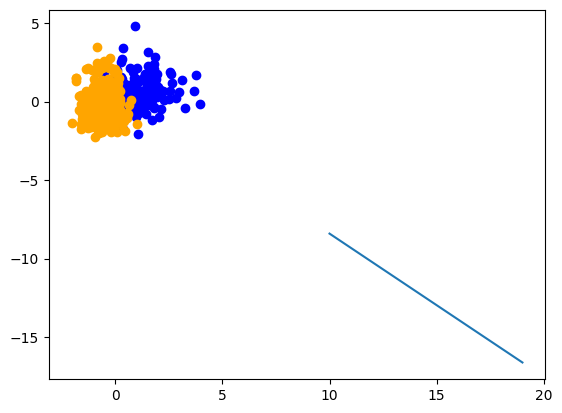

In [ ]:
plt.scatter(data["mean radius"][data["target"] == 0], data["mean texture"][data["target"] == 0], color="blue")
plt.scatter(data["mean radius"][data["target"] == 1], data["mean texture"][data["target"] == 1], color="orange")
#X = svm_model.support_vectors_[:, 0]
#Y = svm_model.support_vectors_[:, 1]
#plt.scatter(X, Y, color = 'red')
plt.plot(np.arange(10, 20), - logistic_model.intercept_ / logistic_model.coef_[0][1]- logistic_model.coef_[0][0] / logistic_model.coef_[0][1] * np.arange(10, 20))

# Линейные модели многоклассовой классификации

In [ ]:
X, Y = datasets.load_iris(return_X_y=True, as_frame=True)
X = X[X.columns[:2]]
print(X)
print(Y)

     sepal length (cm)  sepal width (cm)
0                  5.1               3.5
1                  4.9               3.0
2                  4.7               3.2
3                  4.6               3.1
4                  5.0               3.6
..                 ...               ...
145                6.7               3.0
146                6.3               2.5
147                6.5               3.0
148                6.2               3.4
149                5.9               3.0

[150 rows x 2 columns]
0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    random_state=42,
    test_size=0.9
)
real = np.vstack(Y_test).reshape(1, -1)[0]

In [ ]:
log_model = OneVsRestClassifier(LogisticRegression(
    penalty=None,
    random_state=42
))

log_model.fit(X_train, Y_train)
predict = log_model.predict(X_test)

print(f"accuracy: {accuracy_score(real, predict)}")
print(f"recall: {recall_score(real, predict, average='micro')}")
print(f"precision: {precision_score(real, predict, average='micro')}")

accuracy: 0.7333333333333333
recall: 0.7333333333333333
precision: 0.7333333333333333


In [ ]:
log_model = OneVsOneClassifier(LogisticRegression(
    penalty=None,
    random_state=42
))

log_model.fit(X_train, Y_train)
predict = log_model.predict(X_test)

print(f"accuracy: {accuracy_score(real, predict)}")
print(f"recall: {recall_score(real, predict, average='micro')}")
print(f"precision: {precision_score(real, predict, average='micro')}")

accuracy: 0.7185185185185186
recall: 0.7185185185185186
precision: 0.7185185185185186


In [ ]:
log_model = LogisticRegression(
    penalty=None,
    random_state=42,
    multi_class='multinomial'
)

log_model.fit(X_train, Y_train)
predict = log_model.predict(X_test)

print(f"accuracy: {accuracy_score(real, predict)}")
print(f"recall: {recall_score(real, predict, average='micro')}")
print(f"precision: {precision_score(real, predict, average='micro')}")

accuracy: 0.7185185185185186
recall: 0.7185185185185186
precision: 0.7185185185185186


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


# KNN

In [ ]:
X, Y = datasets.load_iris(return_X_y=True, as_frame=True)
X = X[X.columns[:2]]
print(X)
print(Y)

     sepal length (cm)  sepal width (cm)
0                  5.1               3.5
1                  4.9               3.0
2                  4.7               3.2
3                  4.6               3.1
4                  5.0               3.6
..                 ...               ...
145                6.7               3.0
146                6.3               2.5
147                6.5               3.0
148                6.2               3.4
149                5.9               3.0

[150 rows x 2 columns]
0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, shuffle=True, test_size=0.5, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train[:5]

array([[-0.54270972,  0.01713978],
       [ 0.42641478,  1.04552653],
       [-0.42156916, -1.78253704],
       [-0.54270972,  2.33100998],
       [-1.02727197, -1.78253704]])

In [ ]:
def kernel_function(r):
  h = 1
  return 1 / np.sqrt(2 * np.pi) * np.exp(-2 * (r / h)**2)

In [ ]:
search_uniform = GridSearchCV(KNeighborsClassifier(), param_grid={"n_neighbors" : [i for i in range(1, 11)]})
search_uniform.fit(X_train, Y_train)
n_neighbors_uniform = list(search_uniform.best_params_.values())[0]

knn_uniform = KNeighborsClassifier(
    n_neighbors = n_neighbors_uniform
)
knn_uniform.fit(X_train, Y_train)

predict_uniform = knn_uniform.predict(X_test)

print("--"*20)
print(f"N neighbors: {n_neighbors_uniform}")
print("KNN uniform predict")
print(f"accuracy: {accuracy_score(Y_test, predict_uniform)}")
print(f"recall: {recall_score(Y_test, predict_uniform, average='micro')}")
print(f"precision: {precision_score(Y_test, predict_uniform, average='micro')}")
print("--"*20)

search_distance = GridSearchCV(KNeighborsClassifier(weights="distance"), param_grid={"n_neighbors" : [i for i in range(1, 11)]})
search_distance.fit(X_train, Y_train)
n_neighbors_distance = list(search_uniform.best_params_.values())[0]

knn_distance = KNeighborsClassifier(
    n_neighbors = n_neighbors_distance,
    weights = "distance"
)
knn_distance.fit(X_train, Y_train)
predict_distance = knn_distance.predict(X_test)

print("--"*20)
print(f"N neighbors: {n_neighbors_distance}")
print("KNN distance predict")
print(f"accuracy: {accuracy_score(Y_test, predict_distance)}")
print(f"recall: {recall_score(Y_test, predict_distance, average='micro')}")
print(f"precision: {precision_score(Y_test, predict_distance, average='micro')}")
print("--"*20)

search_kernel = GridSearchCV(KNeighborsClassifier(weights=kernel_function), param_grid={"n_neighbors" : [i for i in range(1, 11)]})
search_kernel.fit(X_train, Y_train)
n_neighbors_kernel = list(search_uniform.best_params_.values())[0]

knn_kernel = KNeighborsClassifier(
    n_neighbors = n_neighbors_kernel,
    weights = kernel_function
)
knn_kernel.fit(X_train, Y_train)
predict_kernel = knn_kernel.predict(X_test)

print("--"*20)
print(f"N neighbors: {n_neighbors_kernel}")
print("KNN kernel predict")
print(f"accuracy: {accuracy_score(Y_test, predict_kernel)}")
print(f"recall: {recall_score(Y_test, predict_kernel, average='micro')}")
print(f"precision: {precision_score(Y_test, predict_kernel, average='micro')}")
print("--"*20)

----------------------------------------
N neighbors: 6
KNN uniform predict
accuracy: 0.76
recall: 0.76
precision: 0.76
----------------------------------------
----------------------------------------
N neighbors: 6
KNN distance predict
accuracy: 0.76
recall: 0.76
precision: 0.76
----------------------------------------
----------------------------------------
N neighbors: 6
KNN kernel predict
accuracy: 0.8
recall: 0.8
precision: 0.8
----------------------------------------


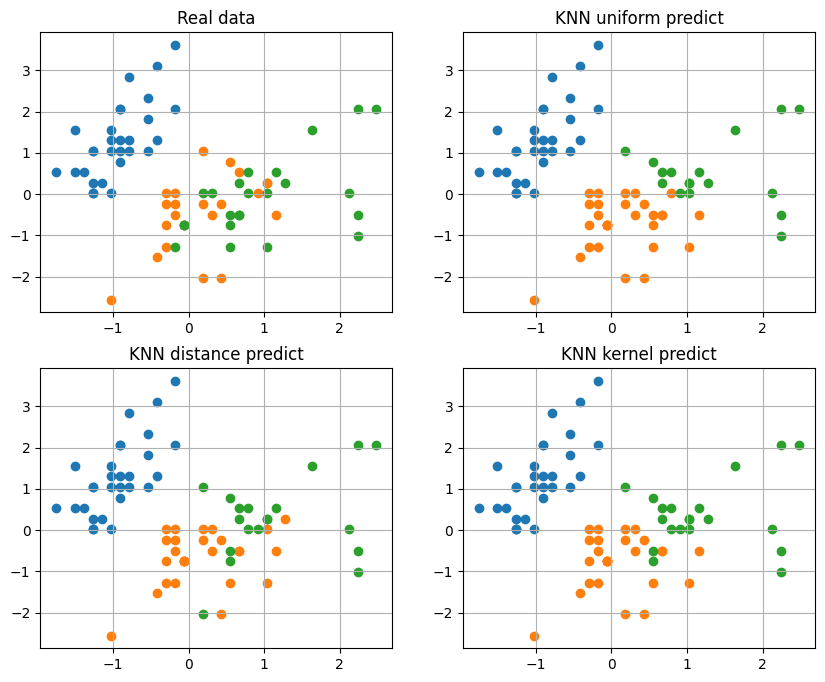

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8))

for cl in [0, 1, 2]:
  ax[0][0].scatter(X_test[np.where(Y_test == cl), 0], X_test[np.where(Y_test == cl), 1])
  ax[0][0].set_title("Real data")
  ax[0][0].grid()

for cl in [0, 1, 2]:
  ax[0][1].scatter(X_test[np.where(predict_uniform == cl), 0], X_test[np.where(predict_uniform == cl), 1])
  ax[0][1].set_title("KNN uniform predict")
  ax[0][1].grid()

for cl in [0, 1, 2]:
  ax[1][0].scatter(X_test[np.where(predict_distance == cl), 0], X_test[np.where(predict_distance == cl), 1])
  ax[1][0].set_title("KNN distance predict")
  ax[1][0].grid()

for cl in [0, 1, 2]:
  ax[1][1].scatter(X_test[np.where(predict_kernel == cl), 0], X_test[np.where(predict_kernel == cl), 1])
  ax[1][1].set_title("KNN kernel predict")
  ax[1][1].grid()


plt.show()


Пробуем с разными ядрами

In [ ]:
def kernel_1(x):
  h = 1
  return 1/2 if x / h < 1 else 0

def kernel_2(x):
  h = 1
  return 1 - x / h if x / h < 1 else 0

def kernel_3(x):
  h = 1
  return 3 / 4 * (1 - x**2) if x / h < 1 else 0

def kernel_4(x):
  h = 1
  return 15 / 16 * (1 - x**2)**2 if x / h < 1 else 0

def kernel_5(x):
  h = 1
  return 1 / np.sqrt(2 * np.pi) * np.exp(- 2 * (x / h)**2)

In [ ]:
class KernelKNN(BaseEstimator, ClassifierMixin):
  def __init__(self, n_neighbors=5, h=1.0, kernel_number = 1):
    self.h = h
    self.n_neighbors = n_neighbors
    self.kernel_number = kernel_number
    self.knn = None

  def kernel(self, dist):
    ratio = dist / self.h

    if self.kernel_number == 1:
      return np.where(ratio < 1, 0.5, 1e-15)
    elif self.kernel_number == 2:
      return np.where(ratio < 1, 1 - ratio, 1e-15)
    elif self.kernel_number == 3:
      return np.where(ratio < 1, 3 / 4 * (1 - ratio**2), 1e-15)
    elif self.kernel_number == 4:
      return np.where(ratio < 1, 15/16 * (1 - ratio**2)**2, 1e-15)
    else:
      return np.where(np.exp(-2 * ratio**2) > 1e-15, 1/(np.sqrt(2*np.pi)) * np.exp(-0.5*ratio**2), 1e-15)

  def fit(self, X_train, Y_train):
    self.knn = KNeighborsClassifier(n_neighbors = self.n_neighbors, weights=lambda x: self.kernel(x))
    self.knn.fit(X_train, Y_train)
    return self

  def predict(self, X):
    return self.knn.predict(X)

  def get_params(self, deep=True):
        return {
            'n_neighbors': self.n_neighbors,
            'h': self.h,
            'kernel_number': self.kernel_number
        }

  def set_params(self, **params):
      for key, value in params.items():
          setattr(self, key, value)
      return self
  def score(self, X, y):
      return self.knn.score(X, y)

In [ ]:
X, Y = datasets.load_digits(return_X_y=True, as_frame=True)
print(X)
print(Y)

      pixel_0_0  pixel_0_1  pixel_0_2  pixel_0_3  pixel_0_4  pixel_0_5  \
0           0.0        0.0        5.0       13.0        9.0        1.0   
1           0.0        0.0        0.0       12.0       13.0        5.0   
2           0.0        0.0        0.0        4.0       15.0       12.0   
3           0.0        0.0        7.0       15.0       13.0        1.0   
4           0.0        0.0        0.0        1.0       11.0        0.0   
...         ...        ...        ...        ...        ...        ...   
1792        0.0        0.0        4.0       10.0       13.0        6.0   
1793        0.0        0.0        6.0       16.0       13.0       11.0   
1794        0.0        0.0        1.0       11.0       15.0        1.0   
1795        0.0        0.0        2.0       10.0        7.0        0.0   
1796        0.0        0.0       10.0       14.0        8.0        1.0   

      pixel_0_6  pixel_0_7  pixel_1_0  pixel_1_1  ...  pixel_6_6  pixel_6_7  \
0           0.0        0.0      

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, shuffle=True, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
for j in [1, 2, 3, 4, 5]:
  search_kernel = GridSearchCV(
      KernelKNN(),
      param_grid={"n_neighbors" : [i for i in range(1, 21)], "h" : [0.1 + 0.2 * i for i in range(10)], "kernel_number" : [j] }
      )
  search_kernel.fit(X_train, Y_train)
  best_params = search_kernel.best_params_
  knn_kernel = KernelKNN(
      n_neighbors = best_params['n_neighbors'],
      h = best_params['h'],
      kernel_number = best_params['kernel_number']
  )
  knn_kernel.fit(X_train, Y_train)
  predict_kernel = knn_kernel.predict(X_test)

  print("--"*20)
  print(f"best parametrs: {best_params}")
  print("KNN kernel predict")
  print(f"accuracy: {accuracy_score(Y_test, predict_kernel)}")
  print(f"recall: {recall_score(Y_test, predict_kernel, average='micro')}")
  print(f"precision: {precision_score(Y_test, predict_kernel, average='micro')}")
  print("--"*20)

----------------------------------------
best parametrs: {'h': 0.1, 'kernel_number': 1, 'n_neighbors': 3}
KNN kernel predict
accuracy: 0.9694444444444444
recall: 0.9694444444444444
precision: 0.9694444444444444
----------------------------------------
----------------------------------------
best parametrs: {'h': 0.1, 'kernel_number': 2, 'n_neighbors': 3}
KNN kernel predict
accuracy: 0.9694444444444444
recall: 0.9694444444444444
precision: 0.9694444444444444
----------------------------------------
----------------------------------------
best parametrs: {'h': 0.1, 'kernel_number': 3, 'n_neighbors': 3}
KNN kernel predict
accuracy: 0.9694444444444444
recall: 0.9694444444444444
precision: 0.9694444444444444
----------------------------------------
----------------------------------------
best parametrs: {'h': 0.1, 'kernel_number': 4, 'n_neighbors': 3}
KNN kernel predict
accuracy: 0.9694444444444444
recall: 0.9694444444444444
precision: 0.9694444444444444
---------------------------------

In [ ]:
for h in [0.1 + i * 0.1 for i in range(100)]:
  search_kernel = GridSearchCV(
      KernelKNN(),
      param_grid={"n_neighbors" : [i for i in range(1, 21)], "h" : [h], "kernel_number" : [5] }
      )
  search_kernel.fit(X_train, Y_train)
  best_params = search_kernel.best_params_
  knn_kernel = KernelKNN(
      n_neighbors = best_params['n_neighbors'],
      h = best_params['h'],
      kernel_number = best_params['kernel_number']
  )
  knn_kernel.fit(X_train, Y_train)
  predict_kernel = knn_kernel.predict(X_test)

  print("--"*20)
  print(f"best parametrs: {best_params}")
  print("KNN kernel predict")
  print(f"accuracy: {accuracy_score(Y_test, predict_kernel)}")
  print(f"recall: {recall_score(Y_test, predict_kernel, average='micro')}")
  print(f"precision: {precision_score(Y_test, predict_kernel, average='micro')}")
  print("--"*20)

----------------------------------------
best parametrs: {'h': 0.1, 'kernel_number': 5, 'n_neighbors': 3}
KNN kernel predict
accuracy: 0.9694444444444444
recall: 0.9694444444444444
precision: 0.9694444444444444
----------------------------------------
----------------------------------------
best parametrs: {'h': 0.2, 'kernel_number': 5, 'n_neighbors': 3}
KNN kernel predict
accuracy: 0.9694444444444444
recall: 0.9694444444444444
precision: 0.9694444444444444
----------------------------------------
----------------------------------------
best parametrs: {'h': 0.30000000000000004, 'kernel_number': 5, 'n_neighbors': 3}
KNN kernel predict
accuracy: 0.9694444444444444
recall: 0.9694444444444444
precision: 0.9694444444444444
----------------------------------------
----------------------------------------
best parametrs: {'h': 0.4, 'kernel_number': 5, 'n_neighbors': 3}
KNN kernel predict
accuracy: 0.9694444444444444
recall: 0.9694444444444444
precision: 0.9694444444444444
-----------------

KNN регрессия

In [ ]:
X, Y = datasets.fetch_california_housing(return_X_y=True, as_frame=True)
X = X[X.columns[:-2]]
print(X)
print(Y)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467
...       ...       ...       ...        ...         ...       ...
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981

[20640 rows x 6 columns]
0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name:

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, shuffle=True, random_state=42, test_size=0.2)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
class KernelKNNRegression(BaseEstimator, ClassifierMixin):
  def __init__(self, n_neighbors=5, h=1.0, kernel_number = 1):
    self.h = h
    self.n_neighbors = n_neighbors
    self.kernel_number = kernel_number
    self.knn = None

  def kernel(self, dist):
    ratio = dist / self.h

    if self.kernel_number == 1:
      return np.where(ratio < 1, 0.5, 1e-15)
    elif self.kernel_number == 2:
      return np.where(ratio < 1, 1 - ratio, 1e-15)
    elif self.kernel_number == 3:
      return np.where(ratio < 1, 3 / 4 * (1 - ratio**2), 1e-15)
    elif self.kernel_number == 4:
      return np.where(ratio < 1, 15/16 * (1 - ratio**2)**2, 1e-15)
    else:
      return np.where(np.exp(-2 * ratio**2) > 1e-15, 1/(np.sqrt(2*np.pi)) * np.exp(-0.5*ratio**2), 1e-15)

  def fit(self, X_train, Y_train):
    self.knn = KNeighborsRegressor(n_neighbors = self.n_neighbors, weights=lambda x: self.kernel(x))
    self.knn.fit(X_train, Y_train)
    return self

  def predict(self, X):
    return self.knn.predict(X)

  def get_params(self, deep=True):
        return {
            'n_neighbors': self.n_neighbors,
            'h': self.h,
            'kernel_number': self.kernel_number
        }

  def set_params(self, **params):
      for key, value in params.items():
          setattr(self, key, value)
      return self
  def score(self, X, y):
      return self.knn.score(X, y)

In [ ]:
search_knn = GridSearchCV(KernelKNNRegression(kernel_number=5),
                          param_grid={"n_neighbors" : list(range(1, 21)),
                                      "h" : [0.1 + i * 0.2 for i in range(3)]
                                      })
search_knn.fit(X_train, Y_train)
best_params_knn = search_knn.best_params_
knn_model = KernelKNNRegression(
    n_neighbors = best_params_knn["n_neighbors"],
    h = best_params_knn["h"],
    kernel_number = 5
)
knn_model.fit(X_train, Y_train)
knn_predict = knn_model.predict(X_test)

print("--"*20)
print(f"KNN")
print(f"KNN parametrs: {best_params_knn}")
print(f"RMSE: {root_mean_squared_error(knn_predict, Y_test)}")
print(f"MAE: {mean_absolute_error(knn_predict, Y_test)}")
print(f"r2-score: {r2_score(y_pred=knn_predict, y_true=Y_test)}")
print("--"*20)

search_linear = GridSearchCV(Ridge(), param_grid={"alpha" : [1e-3 * (i + 1) * 10 for i in range(7)]})
search_linear.fit(X_train, Y_train)
best_params_ridge = search_linear.best_params_
ridge_model = Ridge(alpha=best_params_ridge["alpha"])
ridge_model.fit(X_train, Y_train)
ridge_predict = ridge_model.predict(X_test)

print("--"*20)
print(f"Ridge")
print(f"Ridge parametrs: {best_params_ridge}")
print(f"RMSE: {root_mean_squared_error(ridge_predict, Y_test)}")
print(f"MAE: {mean_absolute_error(ridge_predict, Y_test)}")
print(f"r2-score: {r2_score(y_pred=ridge_predict, y_true=Y_test)}")
print("--"*20)

----------------------------------------
KNN
KNN parametrs: {'h': 0.30000000000000004, 'n_neighbors': 20}
RMSE: 0.7192776019623527
MAE: 0.5127106723912326
r2-score: 0.6051917551883534
----------------------------------------
----------------------------------------
Ridge
Ridge parametrs: {'alpha': 0.07}
RMSE: 0.8013637815061965
MAE: 0.5792149549594287
r2-score: 0.5099362710625028
----------------------------------------


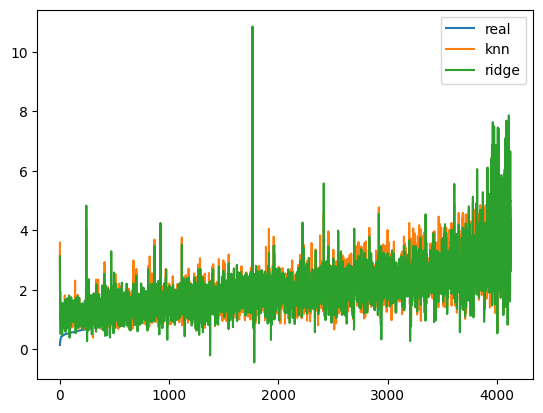

In [ ]:
df = pd.DataFrame(data = {
    "real" : Y_test,
    "knn" : knn_predict,
    "ridge" : ridge_predict
})
df.sort_values("real", inplace=True)
plt.plot(np.arange(len(Y_test)), df["real"], label="real")
plt.plot(np.arange(len(Y_test)), df["knn"], label="knn")
plt.plot(np.arange(len(Y_test)), df["ridge"], label="ridge")
plt.legend()

# Решающие деревья

In [ ]:
data = datasets.load_iris(return_X_y=True, as_frame=True)
X = data[0]
Y = data[1]
print(X)
print(Y)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]
0      0
1      0
2      0
3      0
4   

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=42, shuffle=True, test_size=0.9)
X_train.iloc[:10], Y_train.iloc[:10]

(     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
 52                 6.9               3.1                4.9               1.5
 130                7.4               2.8                6.1               1.9
 103                6.3               2.9                5.6               1.8
 99                 5.7               2.8                4.1               1.3
 116                6.5               3.0                5.5               1.8
 87                 6.3               2.3                4.4               1.3
 74                 6.4               2.9                4.3               1.3
 121                5.6               2.8                4.9               2.0
 149                5.9               3.0                5.1               1.8
 20                 5.4               3.4                1.7               0.2,
 52     1
 130    2
 103    2
 99     1
 116    2
 87     1
 74     1
 121    2
 149    2
 20     0
 Name: target, dtype: int64)

In [ ]:
grid_decision = GridSearchCV(DecisionTreeClassifier(), param_grid={
    "criterion" : ["gini", "entropy"],
    "max_depth" : list(range(1, 6)),
    "min_samples_leaf" : list(range(1, 6))
})
grid_decision.fit(X_train, Y_train)
result = grid_decision.best_params_


decision_model = DecisionTreeClassifier(criterion=result["criterion"], max_depth=result["max_depth"], min_samples_leaf=result["min_samples_leaf"])
decision_model.fit(X_train, Y_train)
Y_pred = decision_model.predict(X_test)

print(f"best_param: {result}")
print(f"accuracy: {accuracy_score(Y_test, Y_pred)}")
print(f"recall: {recall_score(Y_test, Y_pred, average='micro')}")
print(f"precision: {precision_score(Y_test, Y_pred, average='micro')}")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


best_param: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 2}
accuracy: 0.8148148148148148
recall: 0.8148148148148148
precision: 0.8148148148148148


In [ ]:
for md in list(range(1, 6)):
  for msl in list(range(1, 6)):
    decision_model = DecisionTreeClassifier(criterion="gini", max_depth=md, min_samples_leaf=msl)
    decision_model.fit(X_train, Y_train)
    Y_pred = decision_model.predict(X_test)
    print(f"max_depth: {md}. min_samples_leaf: {msl}")
    print(f"accuracy: {accuracy_score(Y_test, Y_pred)}")
    print(f"recall: {recall_score(Y_test, Y_pred, average='micro')}")
    print(f"precision: {precision_score(Y_test, Y_pred, average='micro')}")
    print("--"*20)

max_depth: 1. min_samples_leaf: 1
accuracy: 0.6476190476190476
recall: 0.6476190476190476
precision: 0.6476190476190476
----------------------------------------
max_depth: 1. min_samples_leaf: 2
accuracy: 0.6476190476190476
recall: 0.6476190476190476
precision: 0.6476190476190476
----------------------------------------
max_depth: 1. min_samples_leaf: 3
accuracy: 0.6476190476190476
recall: 0.6476190476190476
precision: 0.6476190476190476
----------------------------------------
max_depth: 1. min_samples_leaf: 4
accuracy: 0.6476190476190476
recall: 0.6476190476190476
precision: 0.6476190476190476
----------------------------------------
max_depth: 1. min_samples_leaf: 5
accuracy: 0.6476190476190476
recall: 0.6476190476190476
precision: 0.6476190476190476
----------------------------------------
max_depth: 2. min_samples_leaf: 1
accuracy: 0.9238095238095239
recall: 0.9238095238095239
precision: 0.9238095238095239
----------------------------------------
max_depth: 2. min_samples_leaf: 2


# Бэггинг на деревьях и knn (по рофлу)

In [ ]:
class ForestClassifier(BaseEstimator, ClassifierMixin):
  def __init__(self, count_tree=100, depth_tree=7, min_samples_leaf=2):
    self.count_tree = count_tree
    self.depth_tree = depth_tree
    self.min_samples_leaf = min_samples_leaf
    self.result_model = np.array([DecisionTreeClassifier(criterion="gini",
                                                        max_depth=self.depth_tree,
                                                        min_samples_leaf=self.min_samples_leaf) for i in range(self.count_tree)])


  def fit(self, X, y):
    for i in range(self.count_tree):
      indices = np.random.choice(np.arange(len(y)), size=len(y), replace=True)
      self.result_model[i].fit(X[indices], y[indices])

  def predict(self, X):
    pred = np.zeros((self.count_tree, len(X)))
    for i in range(self.count_tree):
      pred[i] = self.result_model[i].predict(X)


    result = np.zeros(len(X))
    pred = pred.T
    for i in range(len(X)):
      unique, counts = np.unique(pred[i], return_counts=True)
      index_argmax = np.argmax(counts)
      result[i] = unique[index_argmax]

    return result


  def get_params(self, deep=True):
        return {
            "count_tree" : self.count_tree,
            "depth_tree" : self.depth_tree,
            "min_samples_leaf" : self.min_samples_leaf
        }

  def set_params(self, **params):
      for key, value in params.items():
          setattr(self, key, value)
      return self

  def score(self, X, y):
      pred = self.predict(X)
      return accuracy_score(pred, y)

In [ ]:
class ForestClassifierKNN(BaseEstimator, ClassifierMixin):
  def __init__(self, count_knn = 100, n_neighbors=5):
    self.count_knn = count_knn
    self.n_neighbors = n_neighbors
    self.result_model = np.array([KNeighborsClassifier(n_neighbors=self.n_neighbors,
                                                       weights="distance") for i in range(self.count_knn)])


  def fit(self, X, y):
    for i in range(self.count_knn):
      indices = np.random.choice(np.arange(len(y)), size=len(y), replace=True)
      self.result_model[i].fit(X[indices], y[indices])

  def predict(self, X):
    pred = np.zeros((self.count_knn, len(X)))
    for i in range(self.count_knn):
      pred[i] = self.result_model[i].predict(X)


    result = np.zeros(len(X))
    pred = pred.T
    for i in range(len(X)):
      unique, counts = np.unique(pred[i], return_counts=True)
      index_argmax = np.argmax(counts)
      result[i] = unique[index_argmax]

    return result


  def get_params(self, deep=True):
        return {
            "count_knn" : self.count_knn,
            "n_neighbors" : self.n_neighbors
        }

  def set_params(self, **params):
      for key, value in params.items():
          setattr(self, key, value)
      return self

  def score(self, X, y):
      pred = self.predict(X)
      return accuracy_score(pred, y)

In [ ]:
data = datasets.load_breast_cancer(return_X_y=True, as_frame=False)
X = data[0]
Y = data[1]
print(X.shape)
print(X[:5])
print(Y[:5])

(569, 30)
[[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
  1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
  6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
  1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
  4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 1.326e+03 8.474e-02 7.864e-02 8.690e-02
  7.017e-02 1.812e-01 5.667e-02 5.435e-01 7.339e-01 3.398e+00 7.408e+01
  5.225e-03 1.308e-02 1.860e-02 1.340e-02 1.389e-02 3.532e-03 2.499e+01
  2.341e+01 1.588e+02 1.956e+03 1.238e-01 1.866e-01 2.416e-01 1.860e-01
  2.750e-01 8.902e-02]
 [1.969e+01 2.125e+01 1.300e+02 1.203e+03 1.096e-01 1.599e-01 1.974e-01
  1.279e-01 2.069e-01 5.999e-02 7.456e-01 7.869e-01 4.585e+00 9.403e+01
  6.150e-03 4.006e-02 3.832e-02 2.058e-02 2.250e-02 4.571e-03 2.357e+01
  2.553e+01 1.525e+02 1.709e+03 1.444e-01 4.245e-01 4.504e-01 2.430e-01
  3.613e-01 8.758e-02]
 [1.142e+01 2.038e+01 7.758e+01 3.861e+02 1.425e-01 2.839

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=42, shuffle=True, test_size=0.7)
X_train[:5], Y_train[:5]

(array([[1.478e+01, 2.394e+01, 9.740e+01, 6.683e+02, 1.172e-01, 1.479e-01,
         1.267e-01, 9.029e-02, 1.953e-01, 6.654e-02, 3.577e-01, 1.281e+00,
         2.450e+00, 3.524e+01, 6.703e-03, 2.310e-02, 2.315e-02, 1.184e-02,
         1.900e-02, 3.224e-03, 1.731e+01, 3.339e+01, 1.146e+02, 9.251e+02,
         1.648e-01, 3.416e-01, 3.024e-01, 1.614e-01, 3.321e-01, 8.911e-02],
        [1.624e+01, 1.877e+01, 1.088e+02, 8.051e+02, 1.066e-01, 1.802e-01,
         1.948e-01, 9.052e-02, 1.876e-01, 6.684e-02, 2.873e-01, 9.173e-01,
         2.464e+00, 2.809e+01, 4.563e-03, 3.481e-02, 3.872e-02, 1.209e-02,
         1.388e-02, 4.081e-03, 1.855e+01, 2.509e+01, 1.269e+02, 1.031e+03,
         1.365e-01, 4.706e-01, 5.026e-01, 1.732e-01, 2.770e-01, 1.063e-01],
        [1.846e+01, 1.852e+01, 1.211e+02, 1.075e+03, 9.874e-02, 1.053e-01,
         1.335e-01, 8.795e-02, 2.132e-01, 6.022e-02, 6.997e-01, 1.475e+00,
         4.782e+00, 8.060e+01, 6.471e-03, 1.649e-02, 2.806e-02, 1.420e-02,
         2.370e-02, 3.7

In [ ]:
grid_decision = GridSearchCV(DecisionTreeClassifier(), param_grid={
    "criterion" : ["gini", "entropy"],
    "max_depth" : list(range(1, 11)),
    "min_samples_leaf" : list(range(1, 6))
})
grid_decision.fit(X_train, Y_train)
result = grid_decision.best_params_


decision_model = DecisionTreeClassifier(criterion=result["criterion"], max_depth=result["max_depth"], min_samples_leaf=result["min_samples_leaf"])
decision_model.fit(X_train, Y_train)
Y_pred = decision_model.predict(X_test)

print(f"best_param: {result}")
print(f"accuracy: {accuracy_score(Y_test, Y_pred)}")
print(f"recall: {recall_score(Y_test, Y_pred, average='micro')}")
print(f"precision: {precision_score(Y_test, Y_pred, average='micro')}")

best_param: {'criterion': 'gini', 'max_depth': 1, 'min_samples_leaf': 1}
accuracy: 0.8922305764411027
recall: 0.8922305764411027
precision: 0.8922305764411027


In [ ]:
grid_forest = GridSearchCV(ForestClassifier(count_tree=1000), param_grid={
    "depth_tree" : list(range(1, 10)),
    "min_samples_leaf" : list(range(1, 6))
})
grid_forest.fit(X_train, Y_train)
result = grid_forest.best_params_


forest = ForestClassifier(count_tree=1000, depth_tree=result["depth_tree"], min_samples_leaf=result["min_samples_leaf"])
forest.fit(X_train, Y_train)
pred = forest.predict(X_test)

print(Y_test[:10])
print(pred[:10])
print(f"Best params: {grid_forest.best_params_}")
print(f"accuracy: {accuracy_score(Y_test, pred)}")
print(f"recall: {recall_score(Y_test, pred, average='binary')}")
print(f"precision: {precision_score(Y_test, pred, average='binary')}")

[1 0 0 1 1 0 0 0 1 1]
[1. 0. 0. 1. 1. 0. 0. 0. 0. 1.]
Best params: {'depth_tree': 1, 'min_samples_leaf': 1}
accuracy: 0.9047619047619048
recall: 0.915057915057915
precision: 0.9367588932806324


In [ ]:
grid_forest_knn = GridSearchCV(ForestClassifierKNN(count_knn=100), param_grid={
    "n_neighbors" : list(range(1, 15, 2))
})
grid_forest_knn.fit(X_train, Y_train)
result = grid_forest_knn.best_params_


forest = ForestClassifierKNN(count_knn=100, n_neighbors=result["n_neighbors"])
forest.fit(X_train, Y_train)
pred = forest.predict(X_test)

print(Y_test[:10])
print(pred[:10])
print(f"Best params: {grid_forest_knn.best_params_}")
print(f"accuracy: {accuracy_score(Y_test, pred)}")
print(f"recall: {recall_score(Y_test, pred, average='binary')}")
print(f"precision: {precision_score(Y_test, pred, average='binary')}")

[1 0 0 1 1 0 0 0 1 1]
[1. 0. 0. 1. 1. 0. 0. 0. 1. 1.]
Best params: {'n_neighbors': 7}
accuracy: 0.9197994987468672
recall: 0.9073359073359073
precision: 0.9670781893004116


# Градиентный бустинг собственного изготовления

Регрессия

In [ ]:
class GradBoostRegressor(BaseEstimator, RegressorMixin):
  def __init__(self, count_tree=100, depth_tree=7, min_samples_leaf=2, learning_rate=0.9):
    self.count_tree = count_tree
    self.depth_tree = depth_tree
    self.min_samples_leaf = min_samples_leaf
    self.learning_rate = learning_rate
    self.result_model = np.array([DecisionTreeRegressor(criterion="squared_error",
                                                        max_depth=self.depth_tree,
                                                        min_samples_leaf=self.min_samples_leaf) for i in range(self.count_tree)])

  def fit(self, X, y):
    self.result_model[0].fit(X, y)
    a = np.zeros(len(y))
    for i in range(1, self.count_tree):
      a += self.learning_rate * self.result_model[i - 1].predict(X)
      self.result_model[i].fit(X, y - a)

  def predict(self, X):
    pred = np.zeros(len(X))
    for i in range(self.count_tree):
      pred += self.learning_rate * self.result_model[i].predict(X)

    return pred


  def get_params(self, deep=True):
        return {
            "count_tree" : self.count_tree,
            "depth_tree" : self.depth_tree,
            "min_samples_leaf" : self.min_samples_leaf,
            "learning_rate" : self.learning_rate
        }

  def set_params(self, **params):
      for key, value in params.items():
          setattr(self, key, value)
      return self

  def score(self, X, y):
      pred = self.predict(X)
      return mean_squared_error(pred, y)

In [ ]:
X, Y = datasets.fetch_california_housing(return_X_y=True)
print(X[:10])
print(Y[:10])

[[ 8.32520000e+00  4.10000000e+01  6.98412698e+00  1.02380952e+00
   3.22000000e+02  2.55555556e+00  3.78800000e+01 -1.22230000e+02]
 [ 8.30140000e+00  2.10000000e+01  6.23813708e+00  9.71880492e-01
   2.40100000e+03  2.10984183e+00  3.78600000e+01 -1.22220000e+02]
 [ 7.25740000e+00  5.20000000e+01  8.28813559e+00  1.07344633e+00
   4.96000000e+02  2.80225989e+00  3.78500000e+01 -1.22240000e+02]
 [ 5.64310000e+00  5.20000000e+01  5.81735160e+00  1.07305936e+00
   5.58000000e+02  2.54794521e+00  3.78500000e+01 -1.22250000e+02]
 [ 3.84620000e+00  5.20000000e+01  6.28185328e+00  1.08108108e+00
   5.65000000e+02  2.18146718e+00  3.78500000e+01 -1.22250000e+02]
 [ 4.03680000e+00  5.20000000e+01  4.76165803e+00  1.10362694e+00
   4.13000000e+02  2.13989637e+00  3.78500000e+01 -1.22250000e+02]
 [ 3.65910000e+00  5.20000000e+01  4.93190661e+00  9.51361868e-01
   1.09400000e+03  2.12840467e+00  3.78400000e+01 -1.22250000e+02]
 [ 3.12000000e+00  5.20000000e+01  4.79752705e+00  1.06182380e+00
   

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, shuffle=True, random_state=42, test_size=0.2)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(X_train[:10])

[[-0.326196    0.34849025 -0.17491646 -0.20836543  0.76827628  0.05137609
  -1.3728112   1.27258656]
 [-0.03584338  1.61811813 -0.40283542 -0.12853018 -0.09890135 -0.11736222
  -0.87669601  0.70916212]
 [ 0.14470145 -1.95271028  0.08821601 -0.25753771 -0.44981806 -0.03227969
  -0.46014647 -0.44760309]
 [-1.01786438  0.58654547 -0.60001532 -0.14515634 -0.00743434  0.07750687
  -1.38217186  1.23269811]
 [-0.17148831  1.14200767  0.3490073   0.08662432 -0.48587717 -0.06883176
   0.5320839  -0.10855122]
 [ 1.43991888 -0.6830824   0.354757   -0.20301335  1.11567503  0.02311056
   0.83162514 -1.13567896]
 [-0.7150133  -0.04826847 -0.45652956 -0.05065191 -0.06284224  0.03414177
  -0.75032705  0.80389721]
 [ 2.15752942  0.66589722  0.25866967 -0.32836526 -0.37594086 -0.06056779
   1.06096141 -1.46974477]
 [-1.25024101 -1.87335854 -0.7601283  -0.18607413 -0.53424915 -0.04003325
  -0.70820406  0.83879961]
 [ 1.33693796 -1.87335854  0.54247395 -0.15252992  7.03640507  0.02571249
  -0.75968772  0.

Best params: {'depth_tree': 6, 'learning_rate': 0.3, 'min_samples_leaf': 2}
RMSE: 0.47990376378651045
MAE: 0.31605281922824424
r2-score: 0.8242475240015334


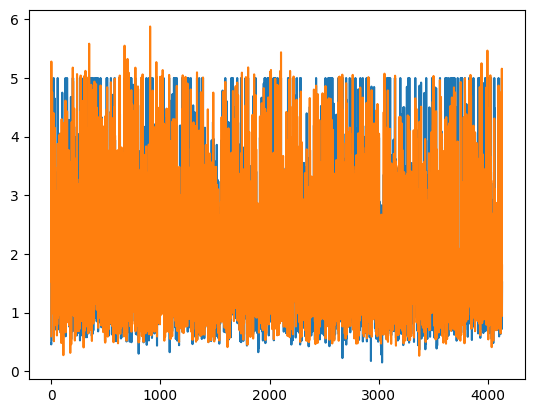

In [ ]:
"""
grid_boosting = GridSearchCV(GradBoostRegressor(count_tree=100), param_grid={
    "depth_tree" : list(range(5, 10)),
    "min_samples_leaf" : list(range(1, 5)),
    "learning_rate" : [0.1, 0.2, 0.3]
})
grid_boosting.fit(X_train, Y_train)
result = grid_boosting.best_params_
"""

boosting = GradBoostRegressor(count_tree=100, depth_tree=6, min_samples_leaf=2, learning_rate=0.3)
boosting.fit(X_train, Y_train)
pred = boosting.predict(X_test)

plt.plot(Y_test)
plt.plot(pred)
print(f"Best params: {result}")
print(f"RMSE: {root_mean_squared_error(Y_test, pred)}")
print(f"MAE: {mean_absolute_error(Y_test, pred)}")
print(f"r2-score: {r2_score(y_pred=pred, y_true=Y_test)}")

Best params: {'max_depth': 4, 'min_samples_leaf': 4}
RMSE: 0.725294407200322
MAE: 0.531930896390397
r2-score: 0.598558934003763


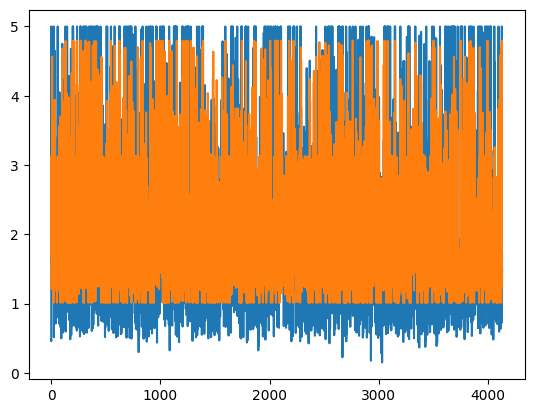

In [ ]:
grid_boosting = GridSearchCV(RandomForestRegressor(n_estimators=10), param_grid={
    "max_depth" : list(range(1, 5)),
    "min_samples_leaf" : list(range(1, 8)),

})
grid_boosting.fit(X_train, Y_train)
result = grid_boosting.best_params_

random_forest_regressor = RandomForestRegressor(n_estimators=100, max_depth=result["max_depth"], min_samples_leaf=result["min_samples_leaf"])
random_forest_regressor.fit(X_train, Y_train)
pred = random_forest_regressor.predict(X_test)


plt.plot(Y_test)
plt.plot(pred)
print(f"Best params: {result}")
print(f"RMSE: {root_mean_squared_error(Y_test, pred)}")
print(f"MAE: {mean_absolute_error(Y_test, pred)}")
print(f"r2-score: {r2_score(y_pred=pred, y_true=Y_test)}")

Классификация

In [ ]:
class GradBoostClassifier(BaseEstimator, ClassifierMixin):
  def __init__(self, count_tree=100, depth_tree=7, min_samples_leaf=2, learning_rate=0.9):
    self.count_tree = count_tree
    self.depth_tree = depth_tree
    self.min_samples_leaf = min_samples_leaf
    self.learning_rate = learning_rate
    self.result_model = [[] for _ in range(count_tree)]


  def softmax(self, logits):
    logits_new = logits - np.max(logits, axis=1, keepdims=True)
    return np.exp(logits_new) / np.sum(np.exp(logits_new), axis=1, keepdims=True)

  def anti_grad(self, q, y_truth):
    return y_truth - q

  def fit(self, X, y):
    self.y_one_hot = pd.get_dummies(y).to_numpy().T
    self.n_classes = self.y_one_hot.shape[0]
    probabilities = np.zeros_like(self.y_one_hot, dtype=np.float64)

    for i in range(self.count_tree):
      q = self.softmax(probabilities)
      for k in range(self.n_classes):
        tree_model = DecisionTreeRegressor(criterion="friedman_mse",
                                            max_depth=self.depth_tree,
                                            min_samples_leaf=self.min_samples_leaf)
        tree_model.fit(X, self.anti_grad(q[k], self.y_one_hot[k]))
        self.result_model[i].append(tree_model)

        probabilities[k] += self.learning_rate * tree_model.predict(X)


  def predict(self, X):
    pred = np.zeros((self.n_classes, len(X)))
    for i in range(self.count_tree):
      for k in range(self.n_classes):
        pred[k] += self.learning_rate * self.result_model[i][k].predict(X)

    return np.argmax(pred, axis=0)

  def get_params(self, deep=True):
        return {
            "count_tree" : self.count_tree,
            "depth_tree" : self.depth_tree,
            "min_samples_leaf" : self.min_samples_leaf,
            "learning_rate" : self.learning_rate
        }

  def set_params(self, **params):
      for key, value in params.items():
          setattr(self, key, value)
      return self

  def score(self, X, y):
      pred = self.predict(X)
      return mean_squared_error(pred, y)

In [ ]:
data = datasets.load_breast_cancer(return_X_y=True, as_frame=False)
X = data[0]
Y = data[1]
print(X.shape)
print(X[:5])
print(Y[:5])

(569, 30)
[[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
  1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
  6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
  1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
  4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 1.326e+03 8.474e-02 7.864e-02 8.690e-02
  7.017e-02 1.812e-01 5.667e-02 5.435e-01 7.339e-01 3.398e+00 7.408e+01
  5.225e-03 1.308e-02 1.860e-02 1.340e-02 1.389e-02 3.532e-03 2.499e+01
  2.341e+01 1.588e+02 1.956e+03 1.238e-01 1.866e-01 2.416e-01 1.860e-01
  2.750e-01 8.902e-02]
 [1.969e+01 2.125e+01 1.300e+02 1.203e+03 1.096e-01 1.599e-01 1.974e-01
  1.279e-01 2.069e-01 5.999e-02 7.456e-01 7.869e-01 4.585e+00 9.403e+01
  6.150e-03 4.006e-02 3.832e-02 2.058e-02 2.250e-02 4.571e-03 2.357e+01
  2.553e+01 1.525e+02 1.709e+03 1.444e-01 4.245e-01 4.504e-01 2.430e-01
  3.613e-01 8.758e-02]
 [1.142e+01 2.038e+01 7.758e+01 3.861e+02 1.425e-01 2.839

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=42, shuffle=True, test_size=0.7)
X_train[:5], Y_train[:5]

(array([[1.478e+01, 2.394e+01, 9.740e+01, 6.683e+02, 1.172e-01, 1.479e-01,
         1.267e-01, 9.029e-02, 1.953e-01, 6.654e-02, 3.577e-01, 1.281e+00,
         2.450e+00, 3.524e+01, 6.703e-03, 2.310e-02, 2.315e-02, 1.184e-02,
         1.900e-02, 3.224e-03, 1.731e+01, 3.339e+01, 1.146e+02, 9.251e+02,
         1.648e-01, 3.416e-01, 3.024e-01, 1.614e-01, 3.321e-01, 8.911e-02],
        [1.624e+01, 1.877e+01, 1.088e+02, 8.051e+02, 1.066e-01, 1.802e-01,
         1.948e-01, 9.052e-02, 1.876e-01, 6.684e-02, 2.873e-01, 9.173e-01,
         2.464e+00, 2.809e+01, 4.563e-03, 3.481e-02, 3.872e-02, 1.209e-02,
         1.388e-02, 4.081e-03, 1.855e+01, 2.509e+01, 1.269e+02, 1.031e+03,
         1.365e-01, 4.706e-01, 5.026e-01, 1.732e-01, 2.770e-01, 1.063e-01],
        [1.846e+01, 1.852e+01, 1.211e+02, 1.075e+03, 9.874e-02, 1.053e-01,
         1.335e-01, 8.795e-02, 2.132e-01, 6.022e-02, 6.997e-01, 1.475e+00,
         4.782e+00, 8.060e+01, 6.471e-03, 1.649e-02, 2.806e-02, 1.420e-02,
         2.370e-02, 3.7

In [ ]:
grad_boosting = GradBoostClassifier(count_tree=10, depth_tree=5, min_samples_leaf=2, learning_rate=0.5)
grad_boosting.fit(X_train, Y_train)
pred = grad_boosting.predict(X_test)

print(Y_test[:10])
print(pred[:10])
#print(f"Best params: {grid_forest_knn.best_params_}")
print(f"accuracy: {accuracy_score(Y_test, pred)}")
print(f"recall: {recall_score(Y_test, pred, average='binary')}")
print(f"precision: {precision_score(Y_test, pred, average='binary')}")

[1 0 0 1 1 0 0 0 1 1]
[1 0 0 1 1 0 0 0 0 1]
accuracy: 0.9097744360902256
recall: 0.9266409266409267
precision: 0.933852140077821


# ROC_AUC

In [ ]:
def positive_negative_separate(Y):
  return np.sum(Y == 1), np.sum(Y == 0)

def ROC_AUC(model, X, Y, count=100, thresholds=None):
  positive, negative = positive_negative_separate(Y)
  predict = model.predict_proba(X)[:, 1]

  if thresholds is None:
    thresholds = np.linspace(0, 1, count)

  TPR_array = np.zeros(len(thresholds))
  FPR_array = np.zeros(len(thresholds))

  for idx, threshold in enumerate(thresholds):
    predict_class = np.where(predict > threshold, 1, 0).astype(int)
    TP = (predict_class == 1) & (Y == 1)
    FP = (predict_class == 1) & (Y == 0)
    TPR = np.sum(TP) / positive
    FPR = np.sum(FP) / negative
    TPR_array[idx] = TPR
    FPR_array[idx] = FPR

  plt.figure(figsize=(8, 6))
  plt.plot(FPR_array, TPR_array)
  plt.grid()
  plt.title("ROC curve")
  plt.xlabel("FPR")
  plt.ylabel("TPR")
  plt.show()

In [ ]:
#Выбор threshold'а для оптимизации recall и precission
def precision_recall_optimisation(model, X, Y, count=100, thresholds=None):
  if thresholds is None:
    thresholds = np.linspace(0, 0.9, count)

  recall_array = np.zeros(len(thresholds))
  precision_array = np.zeros(len(thresholds))
  predict_proba = model.predict_proba(X)[:, 1]

  for idx, threshold in enumerate(thresholds):
    predict = np.where(predict_proba >threshold, 1, 0)
    recall_array[idx] = recall_score(y_pred=predict, y_true=Y)
    precision_array[idx] = precision_score(y_pred=predict, y_true=Y)


  plt.plot(thresholds, recall_array, label=["recall"])
  plt.plot(thresholds, precision_array, label=["precision"])
  plt.grid()
  plt.legend()
  plt.xlabel("thresholds")
  plt.ylabel("metrics")
  plt.show()

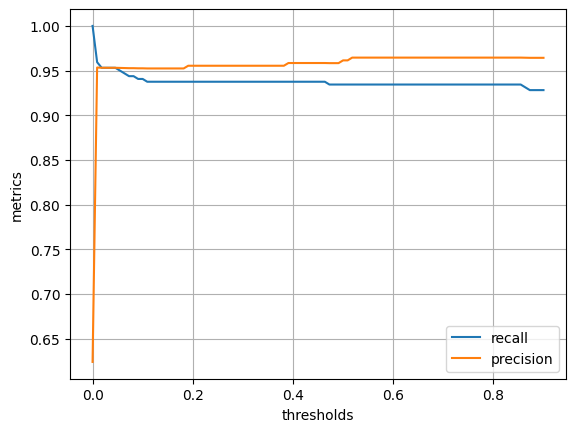

In [ ]:
precision_recall_optimisation(logistic_model, X_test, Y_test, count=100)

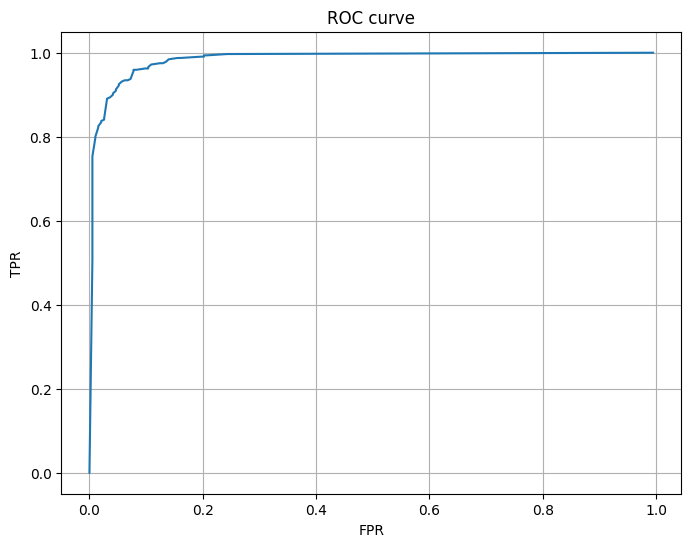

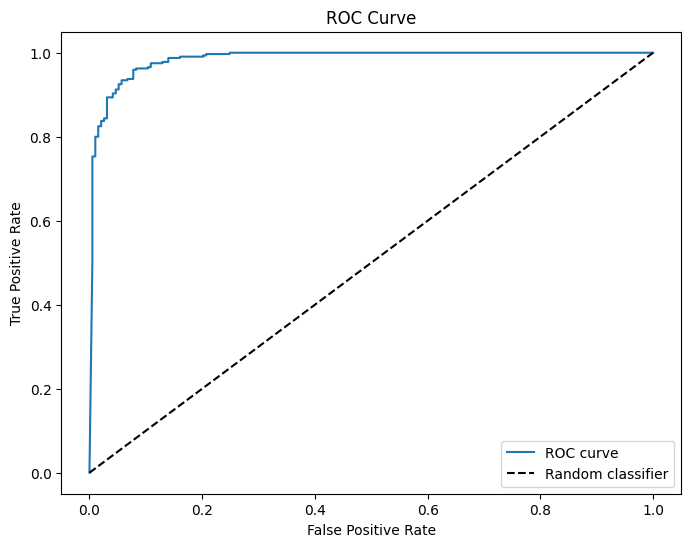

In [ ]:

fpr, tpr, thresholds = roc_curve(Y_test, predict_logistic)
ROC_AUC(logistic_model, X_test, Y_test, count=46, thresholds=thresholds)
#print(thresholds)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()


In [ ]:
data = datasets.load_breast_cancer(return_X_y=True, as_frame=True)
n_columns = -8
data_feaches = data[0][data[0].columns[:n_columns]]
data_target = data[1]
#print(data_feaches.head())
print()
#print(data_target.head())

print(f"Count target = 0: {len(data_target[data_target == 0])}")
print(f"Count target = 1: {len(data_target[data_target == 1])}")


Count target = 0: 212
Count target = 1: 357


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(data_feaches, data_target, test_size=0.9, random_state=42)
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)
real = np.vstack(Y_test).reshape(1, -1)[0]
data = pd.concat([pd.concat([X_train, X_test], axis=0), pd.concat([Y_train, Y_test], axis=0)], axis=1)
#data

In [ ]:
logistic_model = LogisticRegression(penalty=None)


logistic_model.fit(X_train, Y_train)
predict_logistic = logistic_model.predict_proba(X_test)[:, 1]

#print((predict_logistic == real).all())

print(len(predict_logistic), end='\n\n')
#print(real)

#print(f"accuracy: {accuracy_score(real, predict_logistic)}")
#print(f"recall: {recall_score(real, predict_logistic)}")
#print(f"precision: {precision_score(real, predict_logistic)}")

513



#TPE своими руками для подбора одного гиперпараметра

In [ ]:
def create_l_g(ratio_separate, gypherparametrs):
  count_l = int(ratio_separate * len(gypherparametrs))
#  count_g = len(gypherparametrs) - count_l
  sorted_gypherparametrs = sorted(gypherparametrs, key=gypherparametrs.get, reverse=True)

  l = sorted_gypherparametrs[:count_l]
  g = sorted_gypherparametrs[count_l:]
  return l, g


def distribution(l_g, x, h=1):
  def K(x, h):
    return 1 / np.sqrt(2 * np.pi) * np.exp(-0.5 * (x / h)**2)

  if isinstance(x, (int, float)):
    result = 0
  else: result = np.zeros_like(x)
  for sample in l_g:
    result = result + K(x - sample, h)
  return result


def sampling(l_g, gp_span, num):
  samples = []

  h = 1
  grid = np.linspace(start=gp_span[0], stop=gp_span[1], num=10000)
  pdf_max = np.max(distribution(l_g, grid, h))
  while len(samples) < num:
    x_candidate = np.random.uniform(gp_span[0], gp_span[1])

    if distribution(l_g, x_candidate, h) > np.random.uniform(0, pdf_max):
      samples.append(x_candidate)
  return np.array(samples)


def find_argmax_of_EI(l, g, gp_span, count_samples=1000):
  samples = sampling(l, gp_span=gp_span, num=count_samples)
  EI = distribution(l, samples, h=1) / distribution(g, samples, h=1)
  argmax_EI = np.argmax(EI)
  return samples[argmax_EI]


#gp_span = (start, finish)
def TPE(estimator, params, gypherparametr_name, X, Y, gp_span, count_start_iter=20, count_all_iter=100, metric="neg_mean_squared_error", cv=5):
  gypherparametrs = dict()
  for i in range(count_start_iter):
    gp = random.random() * (gp_span[1] - gp_span[0]) + gp_span[0]
    params[gypherparametr_name] = gp
    gypherparametrs[gp] = cross_val_score(estimator(**params), X, Y, cv=cv, scoring=metric).mean()

  l, g = create_l_g(ratio_separate=0.25, gypherparametrs=gypherparametrs)

  for i in range(count_all_iter - count_start_iter):
    argmax_EI = find_argmax_of_EI(l, g, gp_span)
    print(f"{i + 1} gypherparametr: {argmax_EI}")

    params[gypherparametr_name] = argmax_EI
    gypherparametrs[argmax_EI] = cross_val_score(estimator(**params), X, Y, cv=cv, scoring=metric).mean()
    l, g = create_l_g(ratio_separate=0.25, gypherparametrs=gypherparametrs)

  return max(gypherparametrs, key=gypherparametrs.get)



In [ ]:
X, Y = datasets.fetch_california_housing(return_X_y=True)
scale = StandardScaler()
X = scale.fit_transform(X)

[[ 2.34476576  0.98214266  0.62855945 -0.15375759 -0.9744286  -0.04959654
   1.05254828 -1.32783522]
 [ 2.33223796 -0.60701891  0.32704136 -0.26333577  0.86143887 -0.09251223
   1.04318455 -1.32284391]
 [ 1.7826994   1.85618152  1.15562047 -0.04901636 -0.82077735 -0.02584253
   1.03850269 -1.33282653]
 [ 0.93296751  1.85618152  0.15696608 -0.04983292 -0.76602806 -0.0503293
   1.03850269 -1.33781784]
 [-0.012881    1.85618152  0.3447108  -0.03290586 -0.75984669 -0.08561576
   1.03850269 -1.33781784]]


In [ ]:
print(TPE(Ridge, params=dict(), gypherparametr_name='alpha', X=X, Y=Y, gp_span=(0.1, 100), count_all_iter=200))

1 gypherparametr: 34.81462129423614
2 gypherparametr: 24.167224370025902
3 gypherparametr: 32.70001444665707
4 gypherparametr: 31.23879199850316
5 gypherparametr: 31.22431444276507
6 gypherparametr: 31.89821995707349
7 gypherparametr: 33.22653077496228
8 gypherparametr: 30.79054967608133
9 gypherparametr: 30.782713402726912
10 gypherparametr: 29.559615904282694
11 gypherparametr: 28.76510637411858
12 gypherparametr: 31.015392979539673
13 gypherparametr: 31.011820259973618
14 gypherparametr: 31.40300578434932
15 gypherparametr: 31.09475590882481
16 gypherparametr: 31.275657729973897
17 gypherparametr: 31.285144826476383
18 gypherparametr: 31.471716491494565
19 gypherparametr: 31.230687239789095
20 gypherparametr: 31.33669154680279
21 gypherparametr: 31.35042845838119
22 gypherparametr: 31.475933572102267
23 gypherparametr: 31.59443285464267
24 gypherparametr: 31.516385104454507
25 gypherparametr: 31.551477038368557
26 gypherparametr: 31.49316656211314
27 gypherparametr: 31.5903090868412

In [ ]:
def objective(trial, X, Y):
  model = Ridge(alpha=trial.suggest_float("alpha", 0.1, 100))

  score = cross_val_score(model, X, Y, cv=5, scoring="neg_mean_squared_error").mean()
  return score

In [ ]:
import cupy as cp

study = optuna.create_study(
    direction = "maximize",
    sampler=optuna.samplers.TPESampler(
        n_startup_trials=20,

    )
)
print("start!")
study.optimize(lambda trial: objective(trial, X, Y), n_trials=200)

[I 2025-10-27 17:56:15,153] A new study created in memory with name: no-name-83555a5e-1afe-42dd-bc92-69a516d6a312
[I 2025-10-27 17:56:15,186] Trial 0 finished with value: -0.5585702281202719 and parameters: {'alpha': 93.87029134175042}. Best is trial 0 with value: -0.5585702281202719.
[I 2025-10-27 17:56:15,214] Trial 1 finished with value: -0.5581836061261316 and parameters: {'alpha': 20.593160162516835}. Best is trial 1 with value: -0.5581836061261316.
[I 2025-10-27 17:56:15,242] Trial 2 finished with value: -0.5585802787529051 and parameters: {'alpha': 94.69616065619833}. Best is trial 1 with value: -0.5581836061261316.
[I 2025-10-27 17:56:15,277] Trial 3 finished with value: -0.558614695720622 and parameters: {'alpha': 97.45883344351299}. Best is trial 1 with value: -0.5581836061261316.
[I 2025-10-27 17:56:15,307] Trial 4 finished with value: -0.5581895120560036 and parameters: {'alpha': 44.57481851414695}. Best is trial 1 with value: -0.5581836061261316.


start!


[I 2025-10-27 17:56:15,336] Trial 5 finished with value: -0.5581888498816518 and parameters: {'alpha': 44.34634048841283}. Best is trial 1 with value: -0.5581836061261316.
[I 2025-10-27 17:56:15,365] Trial 6 finished with value: -0.5582896395708778 and parameters: {'alpha': 64.66139062175226}. Best is trial 1 with value: -0.5581836061261316.
[I 2025-10-27 17:56:15,393] Trial 7 finished with value: -0.5581788024925569 and parameters: {'alpha': 40.209714345628825}. Best is trial 7 with value: -0.5581788024925569.
[I 2025-10-27 17:56:15,428] Trial 8 finished with value: -0.5581807629577078 and parameters: {'alpha': 21.772326343554173}. Best is trial 7 with value: -0.5581788024925569.
[I 2025-10-27 17:56:15,456] Trial 9 finished with value: -0.5585430230943553 and parameters: {'alpha': 91.58750950861518}. Best is trial 7 with value: -0.5581788024925569.
[I 2025-10-27 17:56:15,484] Trial 10 finished with value: -0.5581871891515108 and parameters: {'alpha': 19.274210176483322}. Best is trial

# Калибровка

In [ ]:
def calibration_diagram(model, X_test, Y_test, n_bins=10):
  pred_prob = model.predict_proba(X_test)[:, 1]

  num = n_bins
  bins = np.linspace(0, 1, num=num + 1)
  truth_prob = np.ones(num)
  for i in range(num):
    mask = (pred_prob >= bins[i]) & (pred_prob < bins[i + 1])
    y_in_bin = Y_test[mask]
    truth_prob[i] = np.sum(y_in_bin) / len(y_in_bin)

  mask = ~np.isnan(truth_prob)
  centre_bins = (bins[1:] + bins[:-1]) / 2

  plt.plot(centre_bins[mask], truth_prob[mask],'.-', label=["our"], markersize=15)
  plt.plot([0, 1], [0, 1],"k--" , label=["ideal"])
  plt.grid()
  plt.legend()
  plt.xlabel("prediction probabilities")
  plt.ylabel("truth probabilities")
  plt.show()

In [ ]:
class hist_calibration:
  def __init__(self, model, n_bins=10):
    self.n_bins = n_bins
    self.model = model


  def fit(self, X, Y):
    pred_prob = self.model.predict_proba(X)[:, 1]
    bins = np.linspace(0, 1, num=self.n_bins + 1)
    self.teta = np.zeros(self.n_bins)

    for i in range(self.n_bins):
      mask = (pred_prob >= bins[i]) & (pred_prob < bins[i + 1])
      y_in_bin = Y[mask]
      self.teta[i] = np.sum(y_in_bin) / len(y_in_bin) if len(y_in_bin) != 0 else 0
    return self.teta

  def predict(self, X):
    pred_first = self.model.predict_proba(X)[:, 1]
    bins = np.linspace(0, 1, num=self.n_bins + 1)

    pred_full = np.zeros_like(pred_first)
    for i in range(self.n_bins):
      mask = (pred_first >= bins[i]) & (pred_first < bins[i + 1])
      pred_full[mask] = self.teta[i]
    return pred_full

In [ ]:
def take_metrics(y_truth, y_pred):
  print(f"Accuracy: {accuracy_score(y_pred=y_pred, y_true=y_truth)}\n" + \
        f"Recall: {recall_score(y_pred=y_pred, y_true=y_truth)}\n" + \
        f"Precision: {precision_score(y_pred=y_pred, y_true=y_truth)}")

In [ ]:
#X, Y = datasets.load_breast_cancer(return_X_y=True, as_frame=False)
X, Y = datasets.make_classification(
    n_samples=100000,           # количество samples
    n_features=25,            # количество features
    n_informative=5,         # информативные features
    n_redundant=5,            # линейно зависимые features
    n_repeated=0,             # дублированные features
    n_classes=2,              # количество классов
#    n_clusters_per_class=1,   # количество кластеров на класс
    random_state=42
)
X_train_val, X_test, Y_train_val, Y_test = train_test_split(X, Y, random_state=42, test_size=0.2)
scaler = StandardScaler()
X_train_val = scaler.fit_transform(X_train_val)
X_test = scaler.transform(X_test)
X_train, X_val, Y_train, Y_val = train_test_split(X_train_val, Y_train_val, random_state=42, test_size=0.5)

In [ ]:
model = LogisticRegression(C=2)
model.fit(X_train, Y_train)
pred = model.predict(X_test)
take_metrics(y_pred=pred, y_truth=Y_test)

Accuracy: 0.8011
Recall: 0.8379210970883434
Precision: 0.7822618053622785


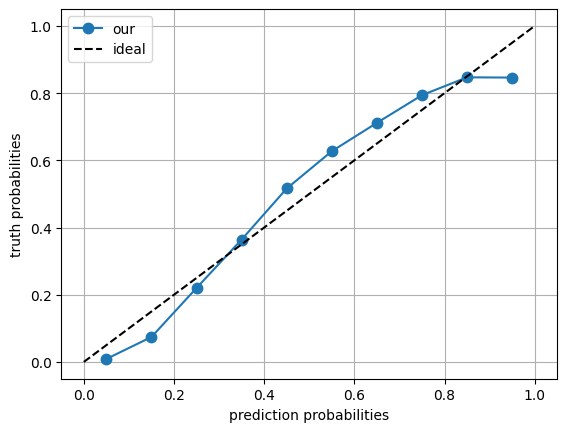

In [ ]:
calibration_diagram(model, X_val, Y_val, n_bins=10)

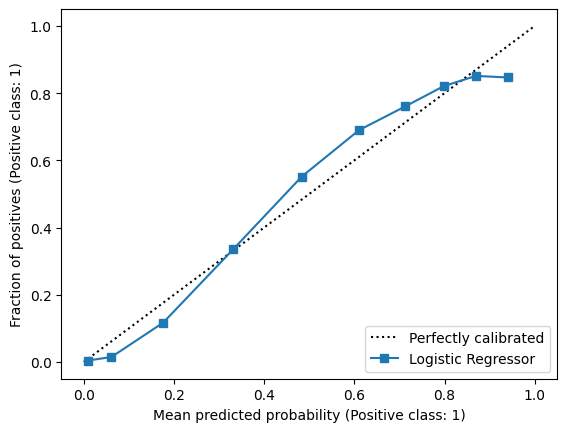

In [ ]:
pred_prob = model.predict_proba(X_val)[:, 1]
fig, ax = plt.subplots()
CalibrationDisplay.from_predictions(
    Y_val,
    pred_prob,
    n_bins=10,
    ax=ax,
    name="Logistic Regressor",
    strategy='quantile'
)

Accuracy: 0.80145
Recall: 0.9059922488323562
Precision: 0.7508647669247241


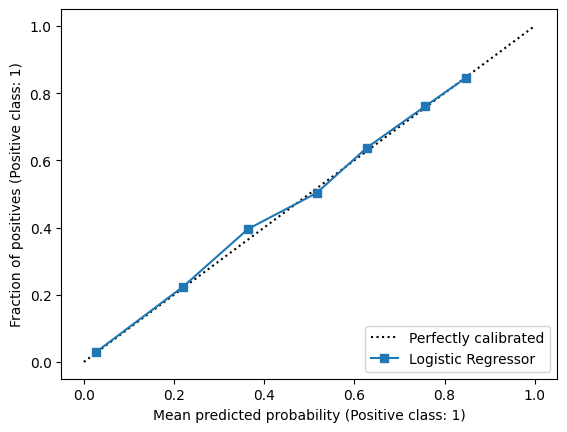

In [ ]:
calibration = hist_calibration(model, n_bins=10)
calibration.fit(X_val, Y_val)
pred_prob = calibration.predict(X_test)


fig, ax = plt.subplots()
CalibrationDisplay.from_predictions(
    Y_test,
    pred_prob,
    n_bins=10,
    ax=ax,
    name="Logistic Regressor",
    strategy='uniform'
)
pred = np.where(pred_prob > 0.5, 1, 0)
take_metrics(y_pred=pred, y_truth=Y_test)

In [ ]:
proba_val = model.predict_proba(X_val)[:, 1]
isotonic = IsotonicRegression(y_min=0, y_max=1, out_of_bounds="clip").fit(proba_val, Y_val)
proba_test = model.predict_proba(X_test)[:, 1]
isotonic_proba = isotonic.transform(proba_test)
isotonic_pred = np.where(isotonic_proba > 0.5, 1, 0)
take_metrics(y_pred=isotonic_pred, y_truth=Y_test)

Accuracy: 0.80415
Recall: 0.8740932127596144
Precision: 0.7684780709418138


# GLM

In [ ]:
class PoissonRegression:
    def __init__(self, lr=0.01, n_iter=1000):
        self.lr=lr
        self.n_iter = n_iter

    def grad_loglikehood(self, X, Y):
        lam = np.exp(X @ self.W)
        grad = X.T @ (Y - lam)
        return grad

    def fit(self, X, Y):
        n_columns = X.shape[1]
        self.W = np.zeros(n_columns)
        for iter in range(self.n_iter):
            grad = self.grad_loglikehood(X, Y)
            self.W += self.lr * grad
        return self.W

    def predict(self, X):
        return np.exp(X @ self.W)


class ExpRegression:
    def __init__(self, lr=0.01, n_iter=100):
        self.lr = lr
        self.n_iter = n_iter

    def grad_likehood(self, X, Y):
        grad = - X.T @ (Y - 1 / (X @ self.W))
        return grad

    def fit(self, X, Y):
        n_columns = X.shape[1]
        self.W = np.ones(n_columns)
        for iter in range(self.n_iter):
            grad = self.grad_likehood(X, Y)
            self.W += self.lr * grad
        return self.W

    def predict(self, X):
        return 1 / (X @ self.W)

RMSE Poisson Regression:  6.24880824179829


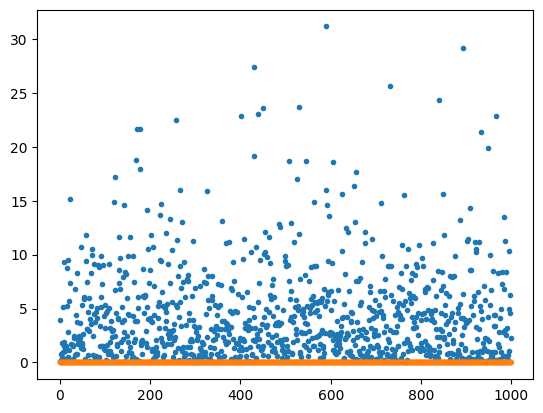

RMSE Ridge Regression:  4.4187625280299745


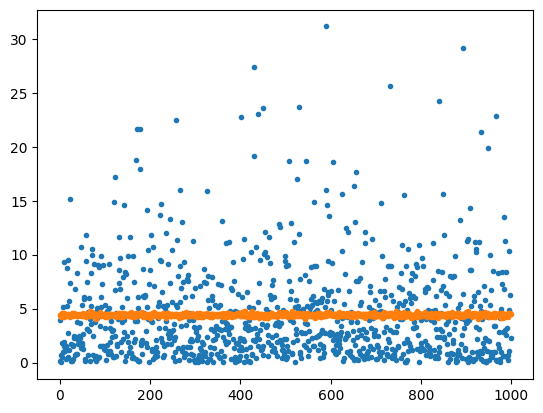

In [ ]:
all_size = 10000
train_size = int(0.9 * all_size)

np.random.seed(42)
# Генерация данных
X = np.random.normal(2, 0.1, (all_size, 2))
true_beta = np.array([0.5, 1.2, 0.8])  # [intercept, coef1, coef2]

# Расчет λ и генерация данных из экспоненциального распределения
X_with_intercept = np.column_stack([np.ones(all_size), X])
linear_pred = X_with_intercept @ true_beta
lambda_true =  1 / linear_pred
Y = np.random.exponential(linear_pred)

pr = ExpRegression(lr=1e-3, n_iter=10000)
pr.fit(X[:train_size], Y[:train_size])
pred = pr.predict(X[train_size:])
plt.plot(Y[train_size:], '.')
plt.plot(pred, '.')
print("RMSE Poisson Regression: ", root_mean_squared_error(pred, Y[train_size:]))
plt.show()

ridge = Ridge(alpha=1.0)
ridge.fit(X[:train_size], Y[:train_size])
pred = ridge.predict(X[train_size:])
plt.plot(Y[train_size:], '.')
plt.plot(pred, '.')
print("RMSE Ridge Regression: ", root_mean_squared_error(pred, Y[train_size:]))

RMSE Poisson Regression:  2.8588458563894847


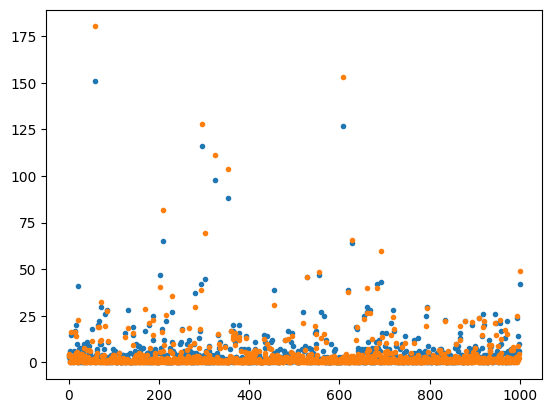

RMSE Ridge Regression:  8.583421963496257


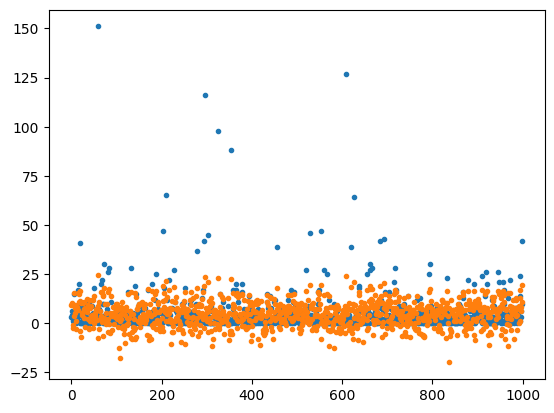

In [ ]:
all_size = 10000
train_size = int(0.9 * all_size)

np.random.seed(42)
# Генерация данных
X = np.random.normal(0, 1, (all_size, 2))
true_beta = np.array([0.5, 1.2, -0.8])  # [intercept, coef1, coef2]

# Расчет λ и генерация данных из распределения Пуассона
X_with_intercept = np.column_stack([np.ones(all_size), X])
linear_pred = X_with_intercept @ true_beta
lambda_true = np.exp(linear_pred)
Y = np.random.poisson(lambda_true)


pr = PoissonRegression(lr=1e-5, n_iter=1000)
pr.fit(X[:train_size], Y[:train_size])
pred = pr.predict(X[train_size:])
plt.plot(Y[train_size:], '.')
plt.plot(pred, '.')
print("RMSE Poisson Regression: ", root_mean_squared_error(pred, Y[train_size:]))
plt.show()

ridge = Ridge(alpha=1.0)
ridge.fit(X[:train_size], Y[:train_size])
pred = ridge.predict(X[train_size:])
plt.plot(Y[train_size:], '.')
plt.plot(pred, '.')
print("RMSE Ridge Regression: ", root_mean_squared_error(pred, Y[train_size:]))

# Решение сорвенования с kaggle (с курса по нейронкам) с помощью методов классического ML

In [ ]:
train_old = pd.read_csv("/content/drive/MyDrive/ML_data/road_accident_risk/train.csv")
test = pd.read_csv("/content/drive/MyDrive/ML_data/road_accident_risk/test.csv")


In [ ]:
target = "accident_risk"
test.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents
0,517754,highway,2,0.34,45,night,clear,True,True,afternoon,True,True,1
1,517755,urban,3,0.04,45,dim,foggy,True,False,afternoon,True,False,0
2,517756,urban,2,0.59,35,dim,clear,True,False,afternoon,True,True,1
3,517757,rural,4,0.95,35,daylight,rainy,False,False,afternoon,False,False,2
4,517758,highway,2,0.86,35,daylight,clear,True,False,evening,False,True,3


In [ ]:
train = train_old.sample(frac=1, random_state=54).reset_index(drop=True)

In [ ]:
def prepare_data(df):
  """
  lights_plus_signs = np.column_stack([df["lighting"].values, df["road_signs_present"]])
  df["lights_plus_signs"] = list(lights_plus_signs)
  df["lights_plus_signs"] = df["lights_plus_signs"].apply(lambda x: str(x[0]) + str(x[1]))
  """

  lights_plus_weather = np.column_stack([df["lighting"].values, df["weather"]])
  df["lights_plus_weather"] = list(lights_plus_weather)
  df["lights_plus_weather"] = df["lights_plus_weather"].apply(lambda x: str(x[0]) + str(x[1]))
  """
  lights_plus_time = np.column_stack([df["lighting"].values, df["time_of_day"]])
  df["lights_plus_time"] = list(lights_plus_time)
  df["lights_plus_time"] = df["lights_plus_time"].apply(lambda x: str(x[0]) + str(x[1]))
  """
  df["strange"] = 0.3 * df["curvature"] + \
                  0.2 * (df["lighting"] == "night").astype(int) + \
                  0.1 * (df["weather"] != "clear").astype(int) + \
                  0.2 * (df["speed_limit"] >= 60).astype(int) + \
                  0.1 * (df["num_reported_accidents"] > 2).astype(int)

In [ ]:
prepare_data(train)
prepare_data(test)

In [ ]:
categorical_columns = ["road_type", "lighting", "weather", "road_signs_present",
                       "public_road", "time_of_day", "holiday", "school_season", "lights_plus_signs", "num_lanes", "lights_plus_weather", "lights_plus_time"]
number_columns = ["curvature", "speed_limit", "num_reported_accidents", "strange"]

target encoding

In [ ]:
data = pd.concat([train, test], axis=0)
dictionary = {}
for col in categorical_columns:
  dictionary[col] = data.groupby(col)[target].mean()
  data[col] = data[col].map(dictionary[col])

In [ ]:
train = data[:len(train)]
test = data[len(train):]

In [ ]:
df = train
df

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk,lights_plus_signs,lights_plus_weather,lights_plus_time
0,98408,0.349997,0.347161,0.12,35,0.470467,0.361494,0.352482,0.347190,0.351428,0.360827,0.352214,1,0.31,0.472389,0.484328,0.472374
1,253724,0.349734,0.351317,0.50,25,0.300109,0.361494,0.352273,0.347190,0.351428,0.343809,0.352539,0,0.28,0.299959,0.316978,0.298801
2,437422,0.357456,0.351317,0.32,60,0.300109,0.386305,0.352273,0.347190,0.354736,0.360827,0.352214,1,0.20,0.299959,0.330851,0.303865
3,230366,0.357456,0.353795,0.39,35,0.300109,0.361494,0.352482,0.347190,0.351428,0.360827,0.352214,0,0.23,0.300261,0.316978,0.298801
4,57487,0.349997,0.351317,0.36,45,0.470467,0.310060,0.352273,0.357518,0.354736,0.343809,0.352539,2,0.22,0.468591,0.423979,0.469456
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517749,267287,0.357456,0.351317,0.61,35,0.470467,0.386305,0.352273,0.347190,0.350966,0.360827,0.352214,1,0.45,0.468591,0.514661,0.469635
517750,323343,0.349997,0.347161,0.89,60,0.302923,0.310060,0.352482,0.357518,0.354736,0.343809,0.352539,3,0.44,0.302927,0.251288,0.305657
517751,344962,0.349997,0.351317,0.59,25,0.300109,0.361494,0.352482,0.347190,0.351428,0.360827,0.352539,1,0.35,0.300261,0.316978,0.298801
517752,367941,0.349997,0.353795,0.59,60,0.302923,0.386305,0.352273,0.347190,0.350966,0.343809,0.352214,0,0.47,0.302920,0.339112,0.300836


one hot encoding

In [ ]:
ohe = OneHotEncoder(handle_unknown="ignore")
help = ohe.fit_transform(train[categorical_columns]).toarray()
df = pd.DataFrame(np.concatenate([np.array(train[number_columns]), help], axis=1),
                  columns=[f'f{i}' for i in range(len(number_columns) + help.shape[1])])
df[target] = train[target]
df = df.drop([], axis='columns')
"""
X_train = np.array(df)
train_size = int(0.9 * len(train))
X_val = X_train[train_size:]
X_train = X_train[:train_size]
Y_train = np.array(train["accident_risk"])
Y_val = Y_train[train_size:]
Y_train = Y_train[:train_size]
X_train, Y_val
"""
df

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f14,f15,f16,f17,f18,f19,f20,f21,f22,accident_risk
0,0.12,1.0,0.336,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.31
1,0.50,0.0,0.250,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.28
2,0.32,1.0,0.396,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.20
3,0.39,0.0,0.217,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.23
4,0.36,2.0,0.308,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517749,0.61,1.0,0.483,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.45
517750,0.89,3.0,0.567,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.44
517751,0.59,1.0,0.277,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.35
517752,0.59,0.0,0.477,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.47


In [ ]:
def objective(trial, train, target_idx):
  max_depth = trial.suggest_int("max_depth", 3, 12)
  learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
  n_estimators = trial.suggest_int("n_estimators", 100, 650)
  reg_lambda = trial.suggest_float("reg_lambda", 0.1, 5)
  subsample = trial.suggest_float("subsample", 0.7, 0.995)


  params={
    'objective': 'count:poisson',
    'max_depth': max_depth,
    'learning_rate': learning_rate,
    'n_estimators': n_estimators,
    'subsample': subsample,
    'colsample_bytree': 1,
    'reg_alpha': 0.005,
    'reg_lambda': reg_lambda,
    'random_state': 69,
    'eval_metric': 'rmse',
    'tree_method' : 'hist',
    'device': 'cuda',
  }

  xgb_model = xgb.XGBRegressor(**params)

  X = cp.asarray(df.loc[:, df.columns != target])
  Y = cp.asarray(df.loc[:, df.columns == target])

  nfolds = 5
  kf = KFold(n_splits=nfolds)

  rmse = 0
  for train_index, val_index in kf.split(X):
    xgb_model.fit(X[train_index], Y[train_index])
    pred = xgb_model.predict(X[val_index])

    rmse += root_mean_squared_error(pred, Y[val_index].get())

  return rmse / nfolds


In [ ]:
import cupy as cp

study = optuna.create_study(
    direction = "minimize",
    sampler=optuna.samplers.TPESampler(
        n_startup_trials=30,
        seed=42,
        multivariate=True,
        group=True
    )
)
print("start!")
study.optimize(lambda trial: objective(trial, df, target), n_trials=100)
#Best RMSE without strange column: 0.0560130069548449

/usr/local/lib/python3.12/dist-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2025-10-28 11:10:59,777] A new study created in memory with name: no-name-53d7e74a-8d0d-4758-a572-7e00550a9148


start!


[I 2025-10-28 11:11:11,414] Trial 0 finished with value: 0.05614429868489405 and parameters: {'max_depth': 6, 'learning_rate': 0.0951207163345817, 'n_estimators': 503, 'reg_lambda': 3.0334265725654794, 'subsample': 0.7460254989305187}. Best is trial 0 with value: 0.05614429868489405.
[I 2025-10-28 11:11:20,592] Trial 1 finished with value: 0.06212758845689185 and parameters: {'max_depth': 4, 'learning_rate': 0.006750277604651747, 'n_estimators': 577, 'reg_lambda': 3.0454635575417233, 'subsample': 0.9088814104498334}. Best is trial 0 with value: 0.05614429868489405.
[I 2025-10-28 11:11:27,975] Trial 2 finished with value: 0.05638643636253848 and parameters: {'max_depth': 3, 'learning_rate': 0.09702107536403744, 'n_estimators': 558, 'reg_lambda': 1.1404616423235534, 'subsample': 0.7536383653260946}. Best is trial 0 with value: 0.05614429868489405.
[I 2025-10-28 11:11:33,808] Trial 3 finished with value: 0.05665399299085324 and parameters: {'max_depth': 4, 'learning_rate': 0.0311199820529

In [ ]:
best_params = study.best_params
best_params

{'max_depth': 6,
 'learning_rate': 0.09406090409648112,
 'n_estimators': 612,
 'reg_lambda': 3.9799128062408005,
 'subsample': 0.852180041578934}

In [ ]:
params={
    'objective': 'count:poisson',
    'max_depth': best_params['max_depth'],
    'learning_rate': best_params['learning_rate'],
    'n_estimators': best_params['n_estimators'],
    'subsample': best_params['subsample'],
    'colsample_bytree': 1,
    'reg_alpha': 0.005,
    'reg_lambda': best_params['reg_lambda'],
    'random_state': 69,
    'eval_metric': 'rmse',
    'tree_method' : 'hist',
    'device': 'cuda',
    }
best_xgb_model = xgb.XGBRegressor(**params)

X = df.loc[:, df.columns != target]
Y = df.loc[:, df.columns == target]
best_xgb_model.fit(X, Y)
print(f"Train RMSE: {root_mean_squared_error(best_xgb_model.predict(X), Y)}")

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:774: UserWarning: [11:47:39] WARNING: /workspace/src/common/error_msg.cc:41: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Train RMSE: 0.0557858869433403


In [ ]:
kf = KFold()

X = df.loc[:, df.columns != target]
Y = df.loc[:, df.columns == target]
for train_idx, val_idx in kf.split(X):
  best_xgb_model.fit(X.iloc[train_idx], Y.iloc[train_idx].to_numpy())
  print(f"Validation rmse: {root_mean_squared_error(best_xgb_model.predict(X.iloc[val_idx]), Y.iloc[val_idx].to_numpy())}\n")

Validation rmse: 0.056199986327567064

Validation rmse: 0.05594725694927468

Validation rmse: 0.05630021555204239

Validation rmse: 0.056325914546063796

Validation rmse: 0.05593143701534061



In [ ]:
help = ohe.transform(test[categorical_columns]).toarray()
df = pd.DataFrame(np.concatenate([np.array(test[number_columns]), help], axis=1),
                  columns=[f'f{i}' for i in range(len(number_columns) + help.shape[1])])
df = df.drop([], axis='columns')
X_test = np.array(df)
pred = best_xgb_model.predict(X_test)
result = pd.DataFrame({'id':test["id"], 'accident_risk':pred})
result

,id,accident_risk
0,517754,0.295867
1,517755,0.116399
2,517756,0.179742
3,517757,0.343233
4,517758,0.405804
...,...,...
172580,690334,0.104143
172581,690335,0.520354
172582,690336,0.248920
172583,690337,0.124610


In [ ]:
result.to_csv("submission.csv", index=False)

#Игрульки

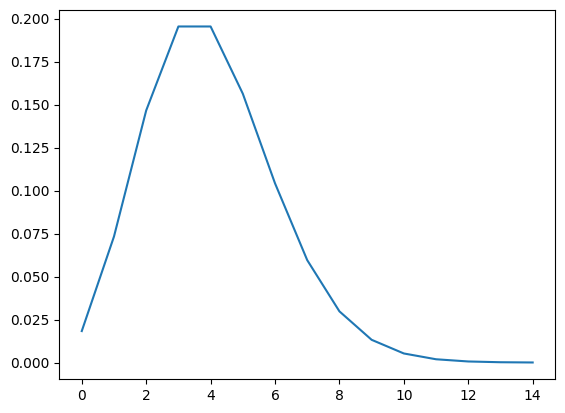

In [ ]:
plt.plot(sps.poisson(mu=4).pmf(np.arange(15)))

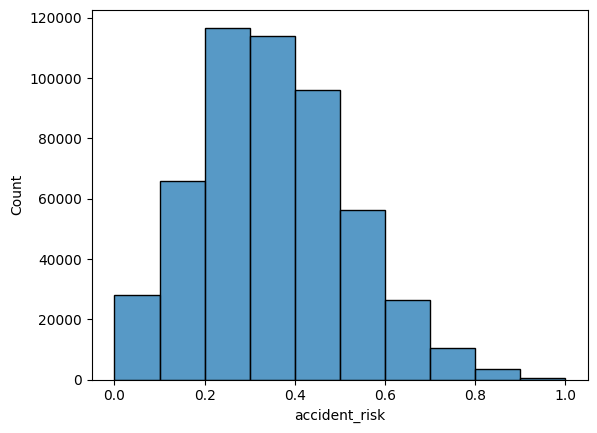

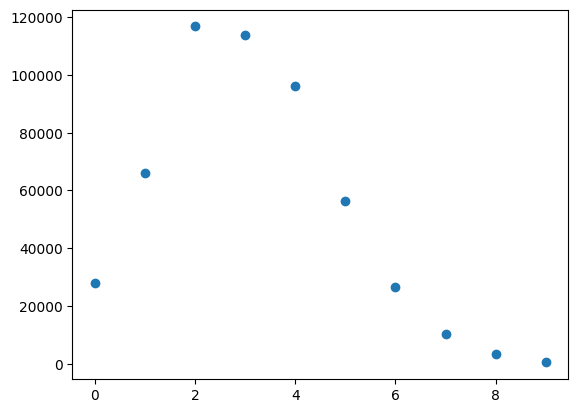

In [ ]:
sns.histplot(train[target], bins=10)
hist = []
count_bins = 10
step = 1 / count_bins
target_data = np.zeros(len(train))
for i in range(count_bins):
  hist.append(train[target][(train[target] < step * (i + 1)) & (train[target] >= step * i)].count())
  target_data[(train[target] < step * (i + 1)) & (train[target] >= step * i)] = i
plt.show()
plt.scatter(np.arange(len(hist)), hist)

[0.05427481 0.12746401 0.22559555 0.21989594 0.1854568  0.10857666
 0.0512618  0.01995156 0.0066943  0.00082858]
[0.0483105  0.14644347 0.2219568  0.2242723  0.16995897 0.10303922
 0.05205707 0.02254292 0.00854178 0.00287696]
Chi-squared: 0.007, p-value: 0.9999999999998056


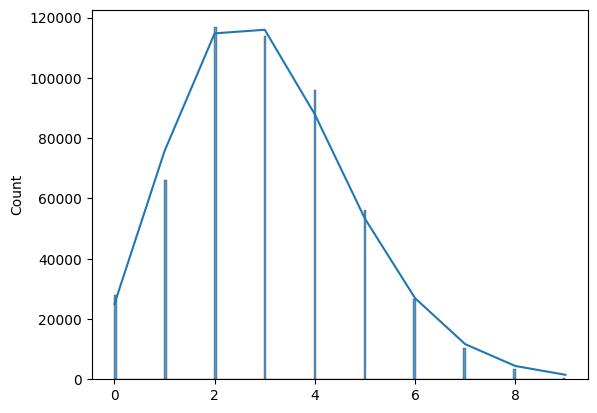

In [ ]:
lambda_est = np.mean(target_data)
values, counts = np.unique(target_data, return_counts=True)
expected = sps.poisson.pmf(values, lambda_est) * len(target_data)

# Нормализуем ожидаемые частоты
expected = expected * np.sum(counts) / np.sum(expected)
expected =expected /  np.sum(expected)
counts = counts / np.sum(counts)

print(counts)
print(expected)
chi2_stat, p_value = sps.chisquare(counts, expected)
print(f"Chi-squared: {chi2_stat:.3f}, p-value: {p_value}")
sns.histplot(target_data)
plt.plot(sps.poisson.pmf(values, lambda_est) * len(target_data))

KstestResult(statistic=np.float64(0.025897105118254382), pvalue=np.float64(0.5053942253747378), statistic_location=np.float64(0.3045465436025056), statistic_sign=np.int8(-1))


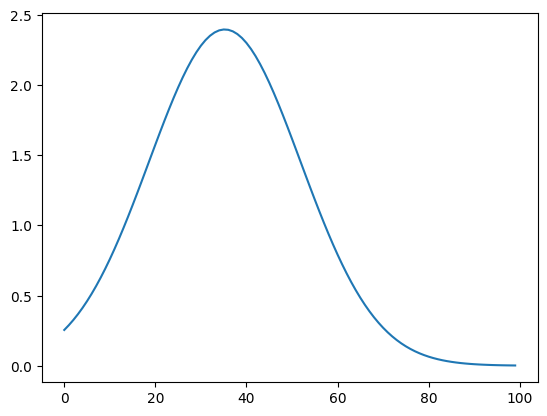

In [ ]:
print(sps.kstest(train[target], "norm", args=(train[target].mean(), train[target].std())))
plt.plot(sps.norm(train[target].mean(), train[target].std()).pdf(np.arange(0, 1, 0.01)))

In [ ]:
train.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,98408,rural,4,0.12,35,night,rainy,True,False,afternoon,True,True,1,0.31
1,253724,highway,1,0.50,25,dim,rainy,False,False,afternoon,False,False,0,0.28
2,437422,urban,1,0.32,60,dim,foggy,False,False,evening,True,True,1,0.20
3,230366,urban,2,0.39,35,dim,rainy,True,False,afternoon,True,True,0,0.23
4,57487,rural,1,0.36,45,night,clear,False,True,evening,False,False,2,0.22
